# explore the log of stock to see whether it is bear soon
# environment: LSTM


Fetching NASDAQ Composite (^IXIC) from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed



══════════════════════════════════
  Dominant Cycles (FFT)
══════════════════════════════════
  #1:    4556 trading days  ≈  18.1 years
  #2:    9112 trading days  ≈  36.2 years
  #3:    3037 trading days  ≈  12.1 years
  #4:     911 trading days  ≈  3.6 years
  #5:    1519 trading days  ≈  6.0 years
══════════════════════════════════

Plot saved → nasdaq_cycle_analysis.png


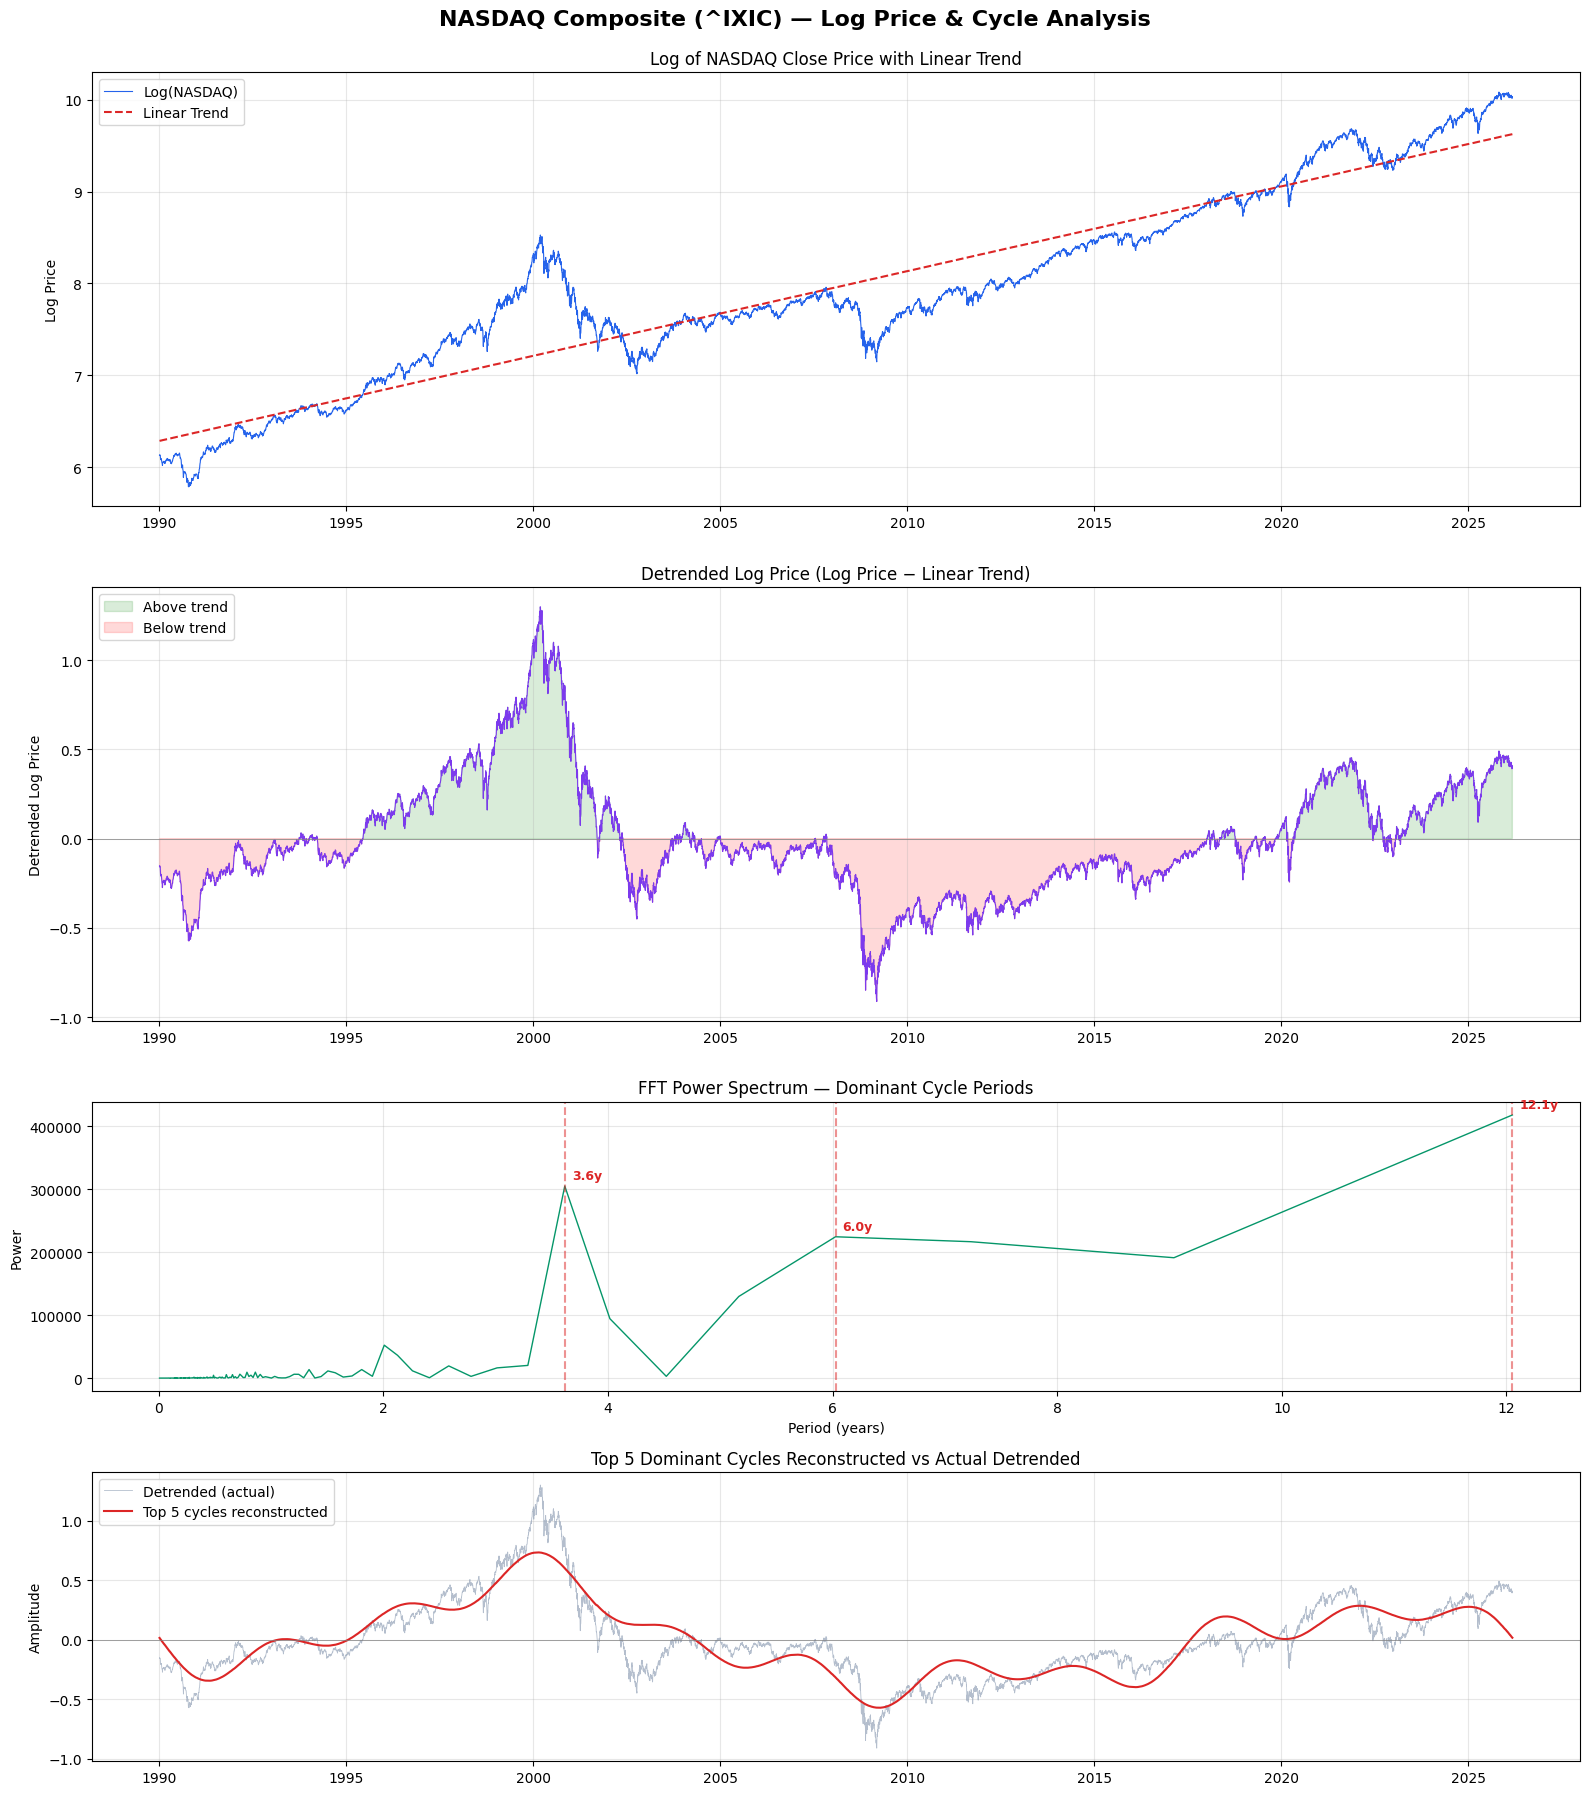

In [ ]:

"""
NASDAQ Composite (纳指) — Log Price & Cycle Analysis
=====================================================
Fetches data from Yahoo Finance, takes log, detrends,
runs FFT to find dominant cycles, and plots everything.

Requirements:
    pip install yfinance matplotlib scipy numpy

Usage:
    python nasdaq_cycle_analysis.py
"""

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── 1. Fetch NASDAQ data ─────────────────────────────────────────────
print("Fetching NASDAQ Composite (^IXIC) from Yahoo Finance...")
nasdaq = yf.download("^IXIC", start="1990-01-01", auto_adjust=True)

close = nasdaq["Close"].dropna()
if hasattr(close, "columns"):
    close = close.iloc[:, 0]

dates = close.index
prices = close.values.astype(float)
log_prices = np.log(prices)

# ── 2. Detrend (remove linear trend from log prices) ─────────────────
x = np.arange(len(log_prices))
coeffs = np.polyfit(x, log_prices, 1)
trend = np.polyval(coeffs, x)
detrended = log_prices - trend

# ── 3. FFT — find dominant cycles ────────────────────────────────────
N = len(detrended)
fft_vals = np.fft.rfft(detrended)
fft_power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(N, d=1)  # 1 trading day

# Ignore DC and ultra-low freqs (period > 20 years)
min_freq_idx = max(1, int(N / (252 * 20)))
fft_power_filtered = fft_power.copy()
fft_power_filtered[:min_freq_idx] = 0

# Top 5 dominant frequencies
TOP_K = 5
top_indices = np.argsort(fft_power_filtered)[-TOP_K:][::-1]
top_freqs = freqs[top_indices]
top_periods_days = 1.0 / top_freqs
top_periods_years = top_periods_days / 252

print("\n══════════════════════════════════")
print("  Dominant Cycles (FFT)")
print("══════════════════════════════════")
for i, (pd, py) in enumerate(zip(top_periods_days, top_periods_years)):
    print(f"  #{i+1}:  {pd:>6.0f} trading days  ≈  {py:.1f} years")
print("══════════════════════════════════\n")

# ── 4. Reconstruct signal from top cycles ─────────────────────────────
reconstructed = np.zeros(N)
for idx in top_indices:
    component = np.zeros(len(fft_vals), dtype=complex)
    component[idx] = fft_vals[idx]
    reconstructed += np.fft.irfft(component, n=N)

# ── 5. Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 18),
                         gridspec_kw={"height_ratios": [3, 3, 2, 2]})
fig.suptitle("NASDAQ Composite (^IXIC) — Log Price & Cycle Analysis",
             fontsize=16, fontweight="bold", y=0.995)

# Panel 1 — Log price + linear trend
ax = axes[0]
ax.plot(dates, log_prices, color="#2563eb", lw=0.8, label="Log(NASDAQ)")
ax.plot(dates, trend, color="#dc2626", lw=1.5, ls="--", label="Linear Trend")
ax.set_ylabel("Log Price")
ax.set_title("Log of NASDAQ Close Price with Linear Trend")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 2 — Detrended log price
ax = axes[1]
ax.plot(dates, detrended, color="#7c3aed", lw=0.8)
ax.axhline(0, color="gray", lw=0.5)
ax.fill_between(dates, detrended, 0, where=detrended > 0,
                alpha=0.15, color="green", label="Above trend")
ax.fill_between(dates, detrended, 0, where=detrended < 0,
                alpha=0.15, color="red", label="Below trend")
ax.set_ylabel("Detrended Log Price")
ax.set_title("Detrended Log Price (Log Price − Linear Trend)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 3 — FFT power spectrum
ax = axes[2]
valid = freqs > 0
periods_yr = (1.0 / freqs[valid]) / 252
power_valid = fft_power[valid]
mask = periods_yr <= 15  # show up to 15-year cycles
ax.plot(periods_yr[mask], power_valid[mask], color="#059669", lw=1)
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power")
ax.set_title("FFT Power Spectrum — Dominant Cycle Periods")
ax.grid(True, alpha=0.3)
for idx in top_indices:
    p_yr = (1.0 / freqs[idx]) / 252
    if p_yr <= 15:
        ax.axvline(p_yr, color="#dc2626", alpha=0.5, ls="--")
        ax.annotate(f"{p_yr:.1f}y", (p_yr, fft_power[idx]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=9, color="#dc2626", fontweight="bold")

# Panel 4 — Reconstructed cycles vs actual
ax = axes[3]
ax.plot(dates, detrended, color="#94a3b8", lw=0.6, alpha=0.7,
        label="Detrended (actual)")
ax.plot(dates, reconstructed, color="#dc2626", lw=1.5,
        label=f"Top {TOP_K} cycles reconstructed")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("Amplitude")
ax.set_title(f"Top {TOP_K} Dominant Cycles Reconstructed vs Actual Detrended")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig("nasdaq_cycle_analysis.png", dpi=150, bbox_inches="tight")
print("Plot saved → nasdaq_cycle_analysis.png")
plt.show()

Fetching NASDAQ Composite (^IXIC) from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed
/Users/ye/opt/anaconda3/envs/lstm/lib/python3.11/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/Users/ye/opt/anaconda3/envs/lstm/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ye/opt/anaconda3/envs/lstm/lib/python3.11/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


Running HP Filter...
Running Kalman Filter (Local Linear Trend + Cycle)... may take a minute
                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                 9112
Model:                    local linear trend   Log Likelihood               25604.421
                   + damped stochastic cycle   AIC                         -51196.842
Date:                       Mon, 09 Mar 2026   BIC                         -51154.140
Time:                               20:37:23   HQIC                        -51182.320
Sample:                                    0                                         
                                      - 9112                                         
Covariance Type:                         opg                                         

══════════════════════════════════════════
  Dominant Cycles (FFT on HP-detrended)
══════════════════════════════════════════
  #1: 

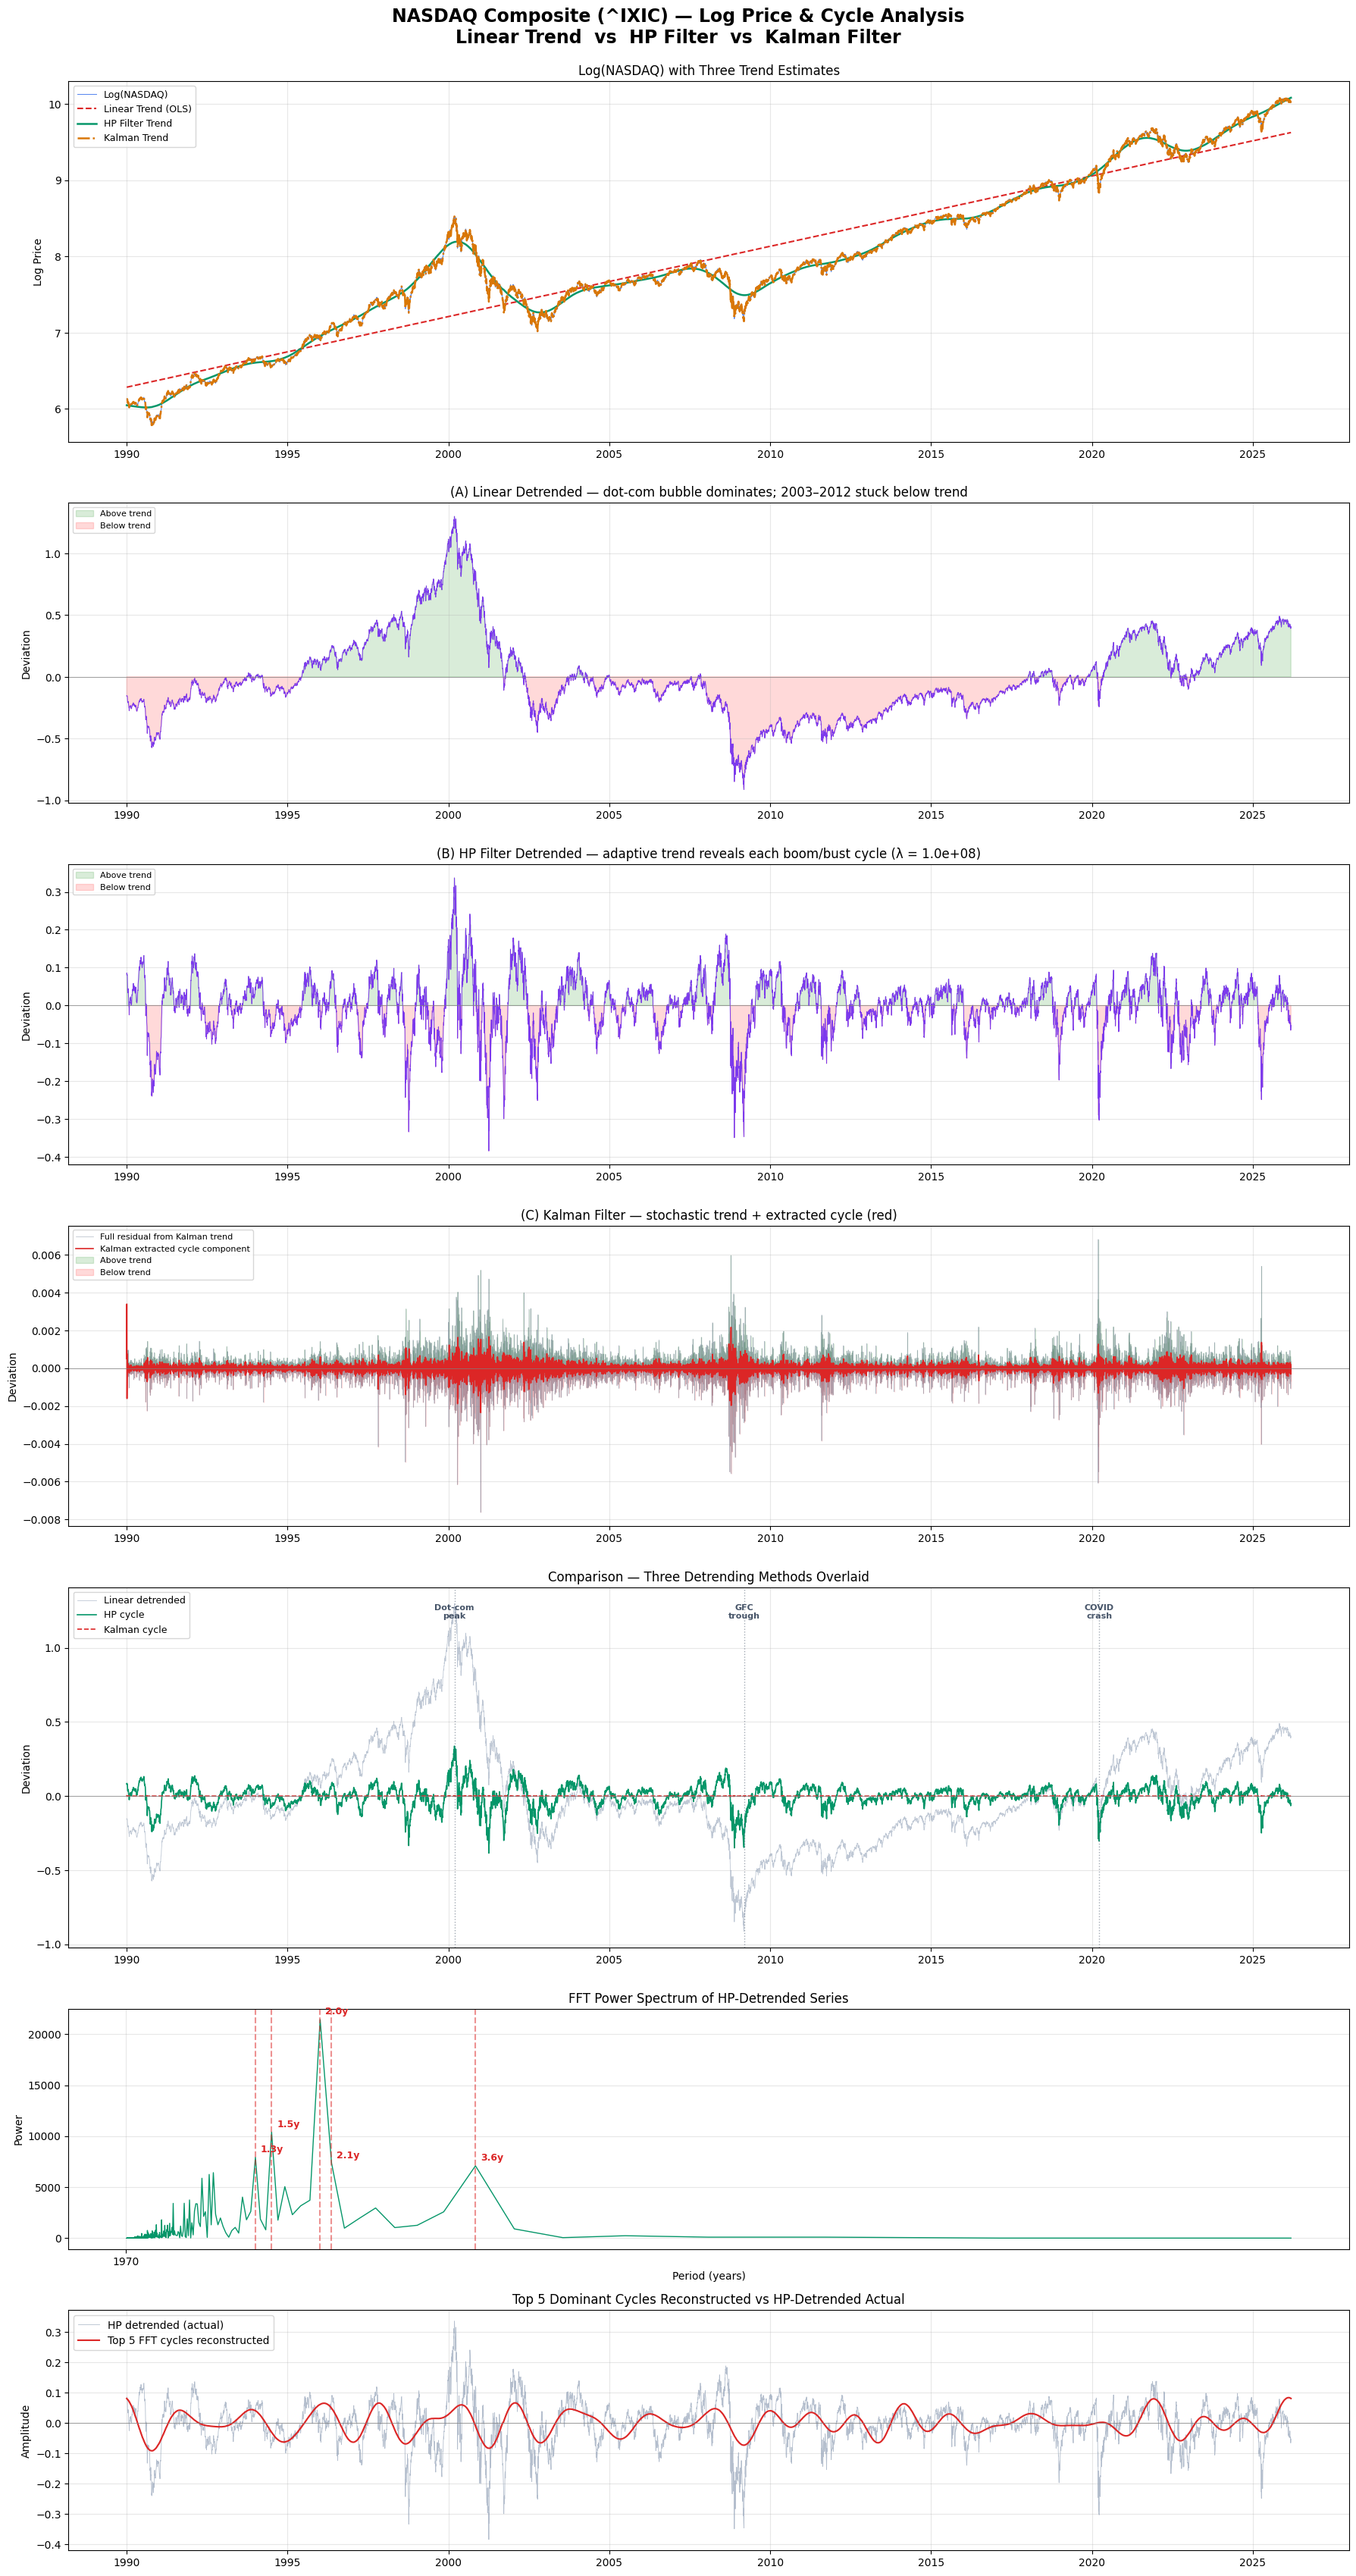

In [3]:
"""
NASDAQ Composite (纳指) — Log Price & Cycle Analysis
=====================================================
Three detrending methods compared:
  1. Linear Trend (OLS)
  2. HP Filter (Hodrick-Prescott)
  3. Kalman Filter (Local Linear Trend model)

Then FFT on the HP-detrended series to find dominant cycles.

Requirements:
    pip install yfinance matplotlib scipy numpy statsmodels

Usage:
    python nasdaq_cycle_analysis.py
"""

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.statespace.structural import UnobservedComponents

# ═══════════════════════════════════════════════════════════════════════
# 1. Fetch NASDAQ data
# ═══════════════════════════════════════════════════════════════════════
print("Fetching NASDAQ Composite (^IXIC) from Yahoo Finance...")
nasdaq = yf.download("^IXIC", start="1990-01-01", auto_adjust=True)

close = nasdaq["Close"].dropna()
if hasattr(close, "columns"):
    close = close.iloc[:, 0]

dates = close.index
prices = close.values.astype(float)
log_prices = np.log(prices)
N = len(log_prices)
x = np.arange(N)

# ═══════════════════════════════════════════════════════════════════════
# 2. Method A — Linear Trend (OLS)
# ═══════════════════════════════════════════════════════════════════════
coeffs = np.polyfit(x, log_prices, 1)
trend_linear = np.polyval(coeffs, x)
cycle_linear = log_prices - trend_linear

# ═══════════════════════════════════════════════════════════════════════
# 3. Method B — HP Filter
#    lambda = 6,812,100 (Ravn-Uhlig rule for daily: 1600 * 252^2)
#    This makes the trend smooth yet adaptive to structural shifts.
# ═══════════════════════════════════════════════════════════════════════
print("Running HP Filter...")
HP_LAMBDA = 1600 * (252 ** 2)   # daily frequency adjustment
cycle_hp, trend_hp = sm.tsa.filters.hpfilter(log_prices, lamb=HP_LAMBDA)

# ═══════════════════════════════════════════════════════════════════════
# 4. Method C — Kalman Filter (Unobserved Components / Local Linear Trend)
#    State-space model:  log_price = trend + cycle + noise
#    - trend follows a random walk with drift
#    - cycle is a stochastic damped cycle
# ═══════════════════════════════════════════════════════════════════════
print("Running Kalman Filter (Local Linear Trend + Cycle)... may take a minute")

log_series = pd.Series(log_prices, index=dates)

model = UnobservedComponents(
    log_series,
    level="local linear trend",   # random-walk level + stochastic slope
    cycle=True,                    # add a stochastic cycle component
    stochastic_cycle=True,
    damped_cycle=True,
)
res = model.fit(disp=False, maxiter=500)
print(res.summary().tables[0])

trend_kalman = res.level["smoothed"]          # extracted trend (level)
cycle_kalman = res.cycle["smoothed"]          # extracted cycle component
detrended_kalman = log_prices - trend_kalman

# Print estimated cycle period from Kalman model
for pname in res.params.index:
    if "period" in pname.lower():
        val = res.params[pname]
        print(f"\nKalman estimated cycle period: {val:.0f} trading days"
              f" ≈ {val / 252:.1f} years")

# ═══════════════════════════════════════════════════════════════════════
# 5. FFT on HP-detrended series (best for cycle detection)
# ═══════════════════════════════════════════════════════════════════════
fft_vals = np.fft.rfft(cycle_hp)
fft_power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(N, d=1)

min_freq_idx = max(1, int(N / (252 * 20)))
fft_power_f = fft_power.copy()
fft_power_f[:min_freq_idx] = 0

TOP_K = 5
top_indices = np.argsort(fft_power_f)[-TOP_K:][::-1]
top_freqs = freqs[top_indices]
top_periods_days = 1.0 / top_freqs
top_periods_years = top_periods_days / 252

print("\n══════════════════════════════════════════")
print("  Dominant Cycles (FFT on HP-detrended)")
print("══════════════════════════════════════════")
for i, (pd_, py_) in enumerate(zip(top_periods_days, top_periods_years)):
    print(f"  #{i+1}:  {pd_:>6.0f} trading days  ≈  {py_:.1f} years")
print("══════════════════════════════════════════\n")

# Reconstruct top cycles from FFT
reconstructed = np.zeros(N)
for idx in top_indices:
    comp = np.zeros(len(fft_vals), dtype=complex)
    comp[idx] = fft_vals[idx]
    reconstructed += np.fft.irfft(comp, n=N)

# ═══════════════════════════════════════════════════════════════════════
# 6. PLOT — 7 panels
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(7, 1, figsize=(18, 34),
                         gridspec_kw={"height_ratios": [3, 2.5, 2.5, 2.5, 3, 2, 2]})
fig.suptitle("NASDAQ Composite (^IXIC) — Log Price & Cycle Analysis\n"
             "Linear Trend  vs  HP Filter  vs  Kalman Filter",
             fontsize=17, fontweight="bold", y=0.998)


def fmt_ax(ax):
    """Common axis formatting."""
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))


def shade(ax, series, dates):
    """Green/red shading above/below zero."""
    ax.fill_between(dates, series, 0, where=series > 0,
                    alpha=0.15, color="green", label="Above trend")
    ax.fill_between(dates, series, 0, where=series < 0,
                    alpha=0.15, color="red", label="Below trend")


# ── Panel 1: Log price + all 3 trends ────────────────────────────────
ax = axes[0]
ax.plot(dates, log_prices, color="#2563eb", lw=0.7, label="Log(NASDAQ)", alpha=0.8)
ax.plot(dates, trend_linear, "#dc2626", lw=1.5, ls="--", label="Linear Trend (OLS)")
ax.plot(dates, trend_hp,     "#059669", lw=1.8,           label="HP Filter Trend")
ax.plot(dates, trend_kalman, "#d97706", lw=1.8, ls="-.",  label="Kalman Trend")
ax.set_ylabel("Log Price")
ax.set_title("Log(NASDAQ) with Three Trend Estimates")
ax.legend(loc="upper left", fontsize=9)
fmt_ax(ax)

# ── Panel 2: Linear detrended ────────────────────────────────────────
ax = axes[1]
ax.plot(dates, cycle_linear, color="#7c3aed", lw=0.7)
ax.axhline(0, color="gray", lw=0.5)
shade(ax, cycle_linear, dates)
ax.set_ylabel("Deviation")
ax.set_title("(A) Linear Detrended — dot-com bubble dominates; 2003–2012 stuck below trend")
ax.legend(loc="upper left", fontsize=8)
fmt_ax(ax)

# ── Panel 3: HP filter detrended ─────────────────────────────────────
ax = axes[2]
ax.plot(dates, cycle_hp, color="#7c3aed", lw=0.7)
ax.axhline(0, color="gray", lw=0.5)
shade(ax, cycle_hp, dates)
ax.set_ylabel("Deviation")
ax.set_title("(B) HP Filter Detrended — adaptive trend reveals each boom/bust cycle "
             f"(λ = {HP_LAMBDA:.1e})")
ax.legend(loc="upper left", fontsize=8)
fmt_ax(ax)

# ── Panel 4: Kalman filter ───────────────────────────────────────────
ax = axes[3]
ax.plot(dates, detrended_kalman, "#64748b", lw=0.5, alpha=0.5, label="Full residual from Kalman trend")
ax.plot(dates, cycle_kalman, "#dc2626", lw=1.2, label="Kalman extracted cycle component")
ax.axhline(0, color="gray", lw=0.5)
shade(ax, detrended_kalman, dates)
ax.set_ylabel("Deviation")
ax.set_title("(C) Kalman Filter — stochastic trend + extracted cycle (red)")
ax.legend(loc="upper left", fontsize=8)
fmt_ax(ax)

# ── Panel 5: Side-by-side comparison ─────────────────────────────────
ax = axes[4]
ax.plot(dates, cycle_linear, "#94a3b8", lw=0.6, alpha=0.6, label="Linear detrended")
ax.plot(dates, cycle_hp,     "#059669", lw=1.2,             label="HP cycle")
ax.plot(dates, cycle_kalman, "#dc2626", lw=1.2, ls="--",    label="Kalman cycle")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("Deviation")
ax.set_title("Comparison — Three Detrending Methods Overlaid")
ax.legend(loc="upper left", fontsize=9)
fmt_ax(ax)

# Mark key events
events = {
    "Dot-com\npeak": "2000-03-10",
    "GFC\ntrough": "2009-03-09",
    "COVID\ncrash": "2020-03-23",
}
for label, date_str in events.items():
    d = pd.Timestamp(date_str)
    idx_ = dates.searchsorted(d)
    if idx_ < len(dates):
        ax.axvline(dates[idx_], color="#475569", alpha=0.5, ls=":", lw=1)
        ax.annotate(label, (dates[idx_], ax.get_ylim()[1] * 0.85),
                    fontsize=8, ha="center", color="#475569", fontweight="bold")

# ── Panel 6: FFT power spectrum (on HP-detrended) ────────────────────
ax = axes[5]
valid = freqs > 0
periods_yr = (1.0 / freqs[valid]) / 252
power_valid = fft_power[valid]
mask = periods_yr <= 15
ax.plot(periods_yr[mask], power_valid[mask], color="#059669", lw=1)
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power")
ax.set_title("FFT Power Spectrum of HP-Detrended Series")
fmt_ax(ax)
for idx in top_indices:
    p_yr = (1.0 / freqs[idx]) / 252
    if p_yr <= 15:
        ax.axvline(p_yr, color="#dc2626", alpha=0.5, ls="--")
        ax.annotate(f"{p_yr:.1f}y", (p_yr, fft_power[idx]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=9, color="#dc2626", fontweight="bold")

# ── Panel 7: Reconstructed top cycles vs HP actual ────────────────────
ax = axes[6]
ax.plot(dates, cycle_hp, "#94a3b8", lw=0.6, alpha=0.7, label="HP detrended (actual)")
ax.plot(dates, reconstructed, "#dc2626", lw=1.5,
        label=f"Top {TOP_K} FFT cycles reconstructed")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("Amplitude")
ax.set_title(f"Top {TOP_K} Dominant Cycles Reconstructed vs HP-Detrended Actual")
ax.legend(loc="upper left")
fmt_ax(ax)

plt.tight_layout()
plt.savefig("nasdaq_cycle_analysis.png", dpi=150, bbox_inches="tight")
print("Plot saved → nasdaq_cycle_analysis.png")
plt.show()

Log 同比均值: 0.1122  (≈ 11.9% 年化)
Log 同比标准差: 0.2371
+1σ = 0.3493,  -1σ = -0.1249


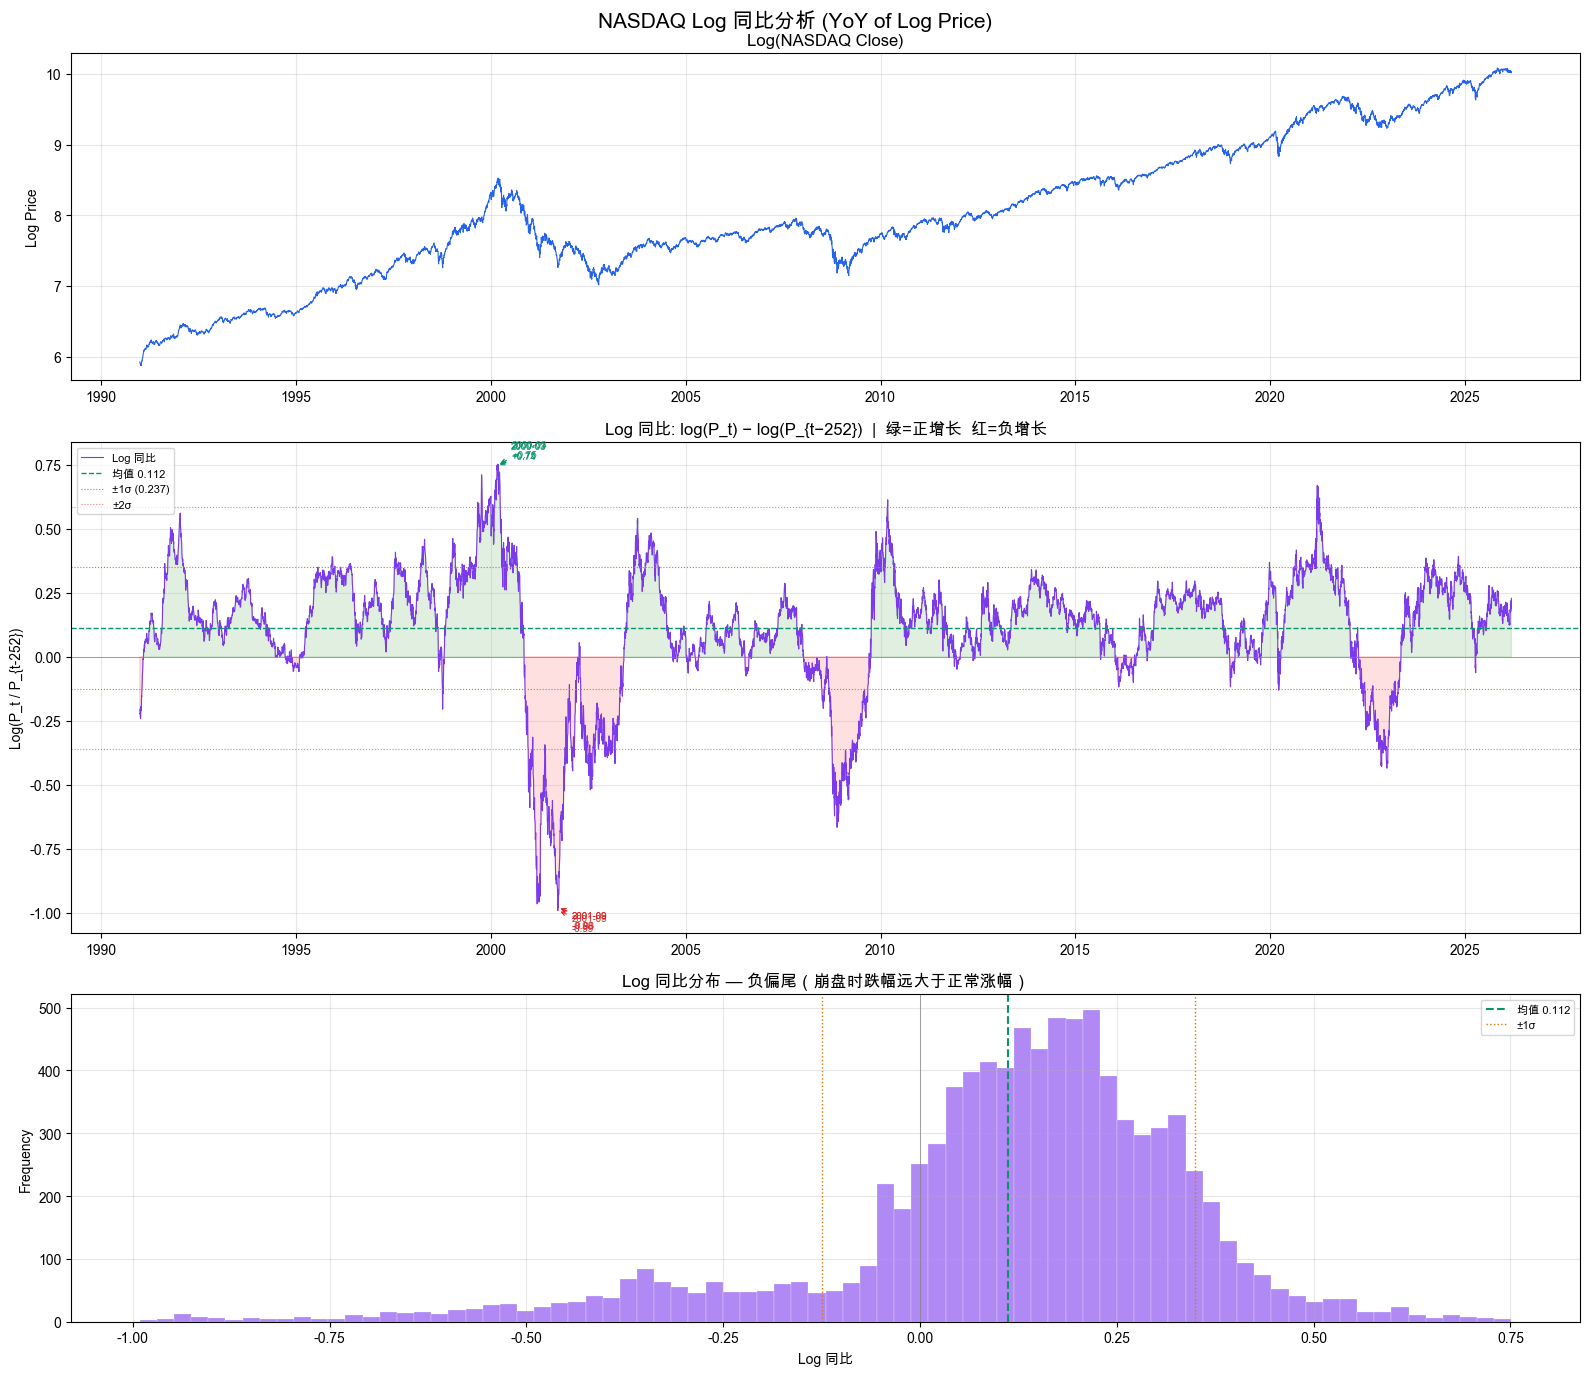

In [5]:
# %% [markdown]
# ## NASDAQ Log 同比 (Year-over-Year Change of Log Price)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti TC", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False   # 解决负号显示为方块


# ── 假设你已经有 close (Series), dates, log_prices ──
# 如果没有，取消下面注释：
# import yfinance as yf
# nasdaq = yf.download("^IXIC", start="1990-01-01", auto_adjust=True)
# close = nasdaq["Close"].dropna()
# if hasattr(close, "columns"):
#     close = close.iloc[:, 0]
# dates = close.index
# prices = close.values.astype(float)
# log_prices = np.log(prices)

# ── 构建 DataFrame ──
df = pd.DataFrame({"log_price": log_prices}, index=dates)

# 同比 = 当日 log price - 252个交易日前的 log price
# 注意：log(P_t) - log(P_{t-252}) = log(P_t / P_{t-252})，即对数收益率（年化）
TRADING_DAYS_PER_YEAR = 252
df["log_yoy"] = df["log_price"] - df["log_price"].shift(TRADING_DAYS_PER_YEAR)
df = df.dropna()

# ── 统计 ──
mean_yoy = df["log_yoy"].mean()
std_yoy  = df["log_yoy"].std()
print(f"Log 同比均值: {mean_yoy:.4f}  (≈ {np.exp(mean_yoy)-1:.1%} 年化)")
print(f"Log 同比标准差: {std_yoy:.4f}")
print(f"+1σ = {mean_yoy + std_yoy:.4f},  -1σ = {mean_yoy - std_yoy:.4f}")

# ── 画图 ──
fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                         gridspec_kw={"height_ratios": [2, 3, 2]})
fig.suptitle("NASDAQ Log 同比分析 (YoY of Log Price)", fontsize=15, fontweight="bold")

def fmt(ax):
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))

# ── Panel 1: Log price 原始 ──
ax = axes[0]
ax.plot(df.index, df["log_price"], color="#2563eb", lw=0.8)
ax.set_ylabel("Log Price")
ax.set_title("Log(NASDAQ Close)")
fmt(ax)

# ── Panel 2: Log 同比 ──
ax = axes[1]
ax.plot(df.index, df["log_yoy"], color="#7c3aed", lw=0.8, label="Log 同比")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(mean_yoy, color="#059669", lw=1, ls="--", label=f"均值 {mean_yoy:.3f}")
ax.axhline(mean_yoy + std_yoy, color="#d97706", lw=0.8, ls=":", label=f"±1σ ({std_yoy:.3f})")
ax.axhline(mean_yoy - std_yoy, color="#d97706", lw=0.8, ls=":")
ax.axhline(mean_yoy + 2*std_yoy, color="#dc2626", lw=0.8, ls=":", alpha=0.6, label="±2σ")
ax.axhline(mean_yoy - 2*std_yoy, color="#dc2626", lw=0.8, ls=":", alpha=0.6)

# 填色
ax.fill_between(df.index, df["log_yoy"], 0,
                where=df["log_yoy"] > 0, alpha=0.12, color="green")
ax.fill_between(df.index, df["log_yoy"], 0,
                where=df["log_yoy"] < 0, alpha=0.12, color="red")

ax.set_ylabel("Log(P_t / P_{t-252})")
ax.set_title("Log 同比: log(P_t) − log(P_{t−252})  |  绿=正增长  红=负增长")
ax.legend(loc="upper left", fontsize=8)
fmt(ax)

# 标注极值事件
extremes = df["log_yoy"].copy()
peaks   = extremes.nlargest(3)
troughs = extremes.nsmallest(3)
for d, v in peaks.items():
    ax.annotate(f"{d.strftime('%Y-%m')}\n{v:+.2f}", (d, v),
                textcoords="offset points", xytext=(10, 5),
                fontsize=7, color="#059669", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#059669", lw=0.8))
for d, v in troughs.items():
    ax.annotate(f"{d.strftime('%Y-%m')}\n{v:+.2f}", (d, v),
                textcoords="offset points", xytext=(10, -15),
                fontsize=7, color="#dc2626", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#dc2626", lw=0.8))

# ── Panel 3: 同比的分布直方图 ──
ax = axes[2]
ax.hist(df["log_yoy"], bins=80, color="#7c3aed", alpha=0.6, edgecolor="white", lw=0.3)
ax.axvline(0, color="gray", lw=0.5)
ax.axvline(mean_yoy, color="#059669", lw=1.5, ls="--", label=f"均值 {mean_yoy:.3f}")
ax.axvline(mean_yoy + std_yoy, color="#d97706", lw=1, ls=":")
ax.axvline(mean_yoy - std_yoy, color="#d97706", lw=1, ls=":", label=f"±1σ")
ax.set_xlabel("Log 同比")
ax.set_ylabel("Frequency")
ax.set_title("Log 同比分布 — 负偏尾（崩盘时跌幅远大于正常涨幅）")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("nasdaq_log_yoy.png", dpi=150, bbox_inches="tight")
plt.show()

拉取数据中...


[*********************100%***********************]  1 of 1 completed


✅ 成功拉取 CFNAI 作为 PMI 代理
数据拉取完成!

  熊市预警仪表盘 — 2026-02
  收益率曲线 (10Y-2Y)        🟢 安全
  信用利差 (HY OAS)         🟢 安全
  失业金申请趋势               🟢 安全
  纳指回撤幅度                🟢 安全

  综合得分: 0 / 8  (0%)
  📊 整体评估: 🟢 低风险

图表已保存 → bear_market_dashboard.png


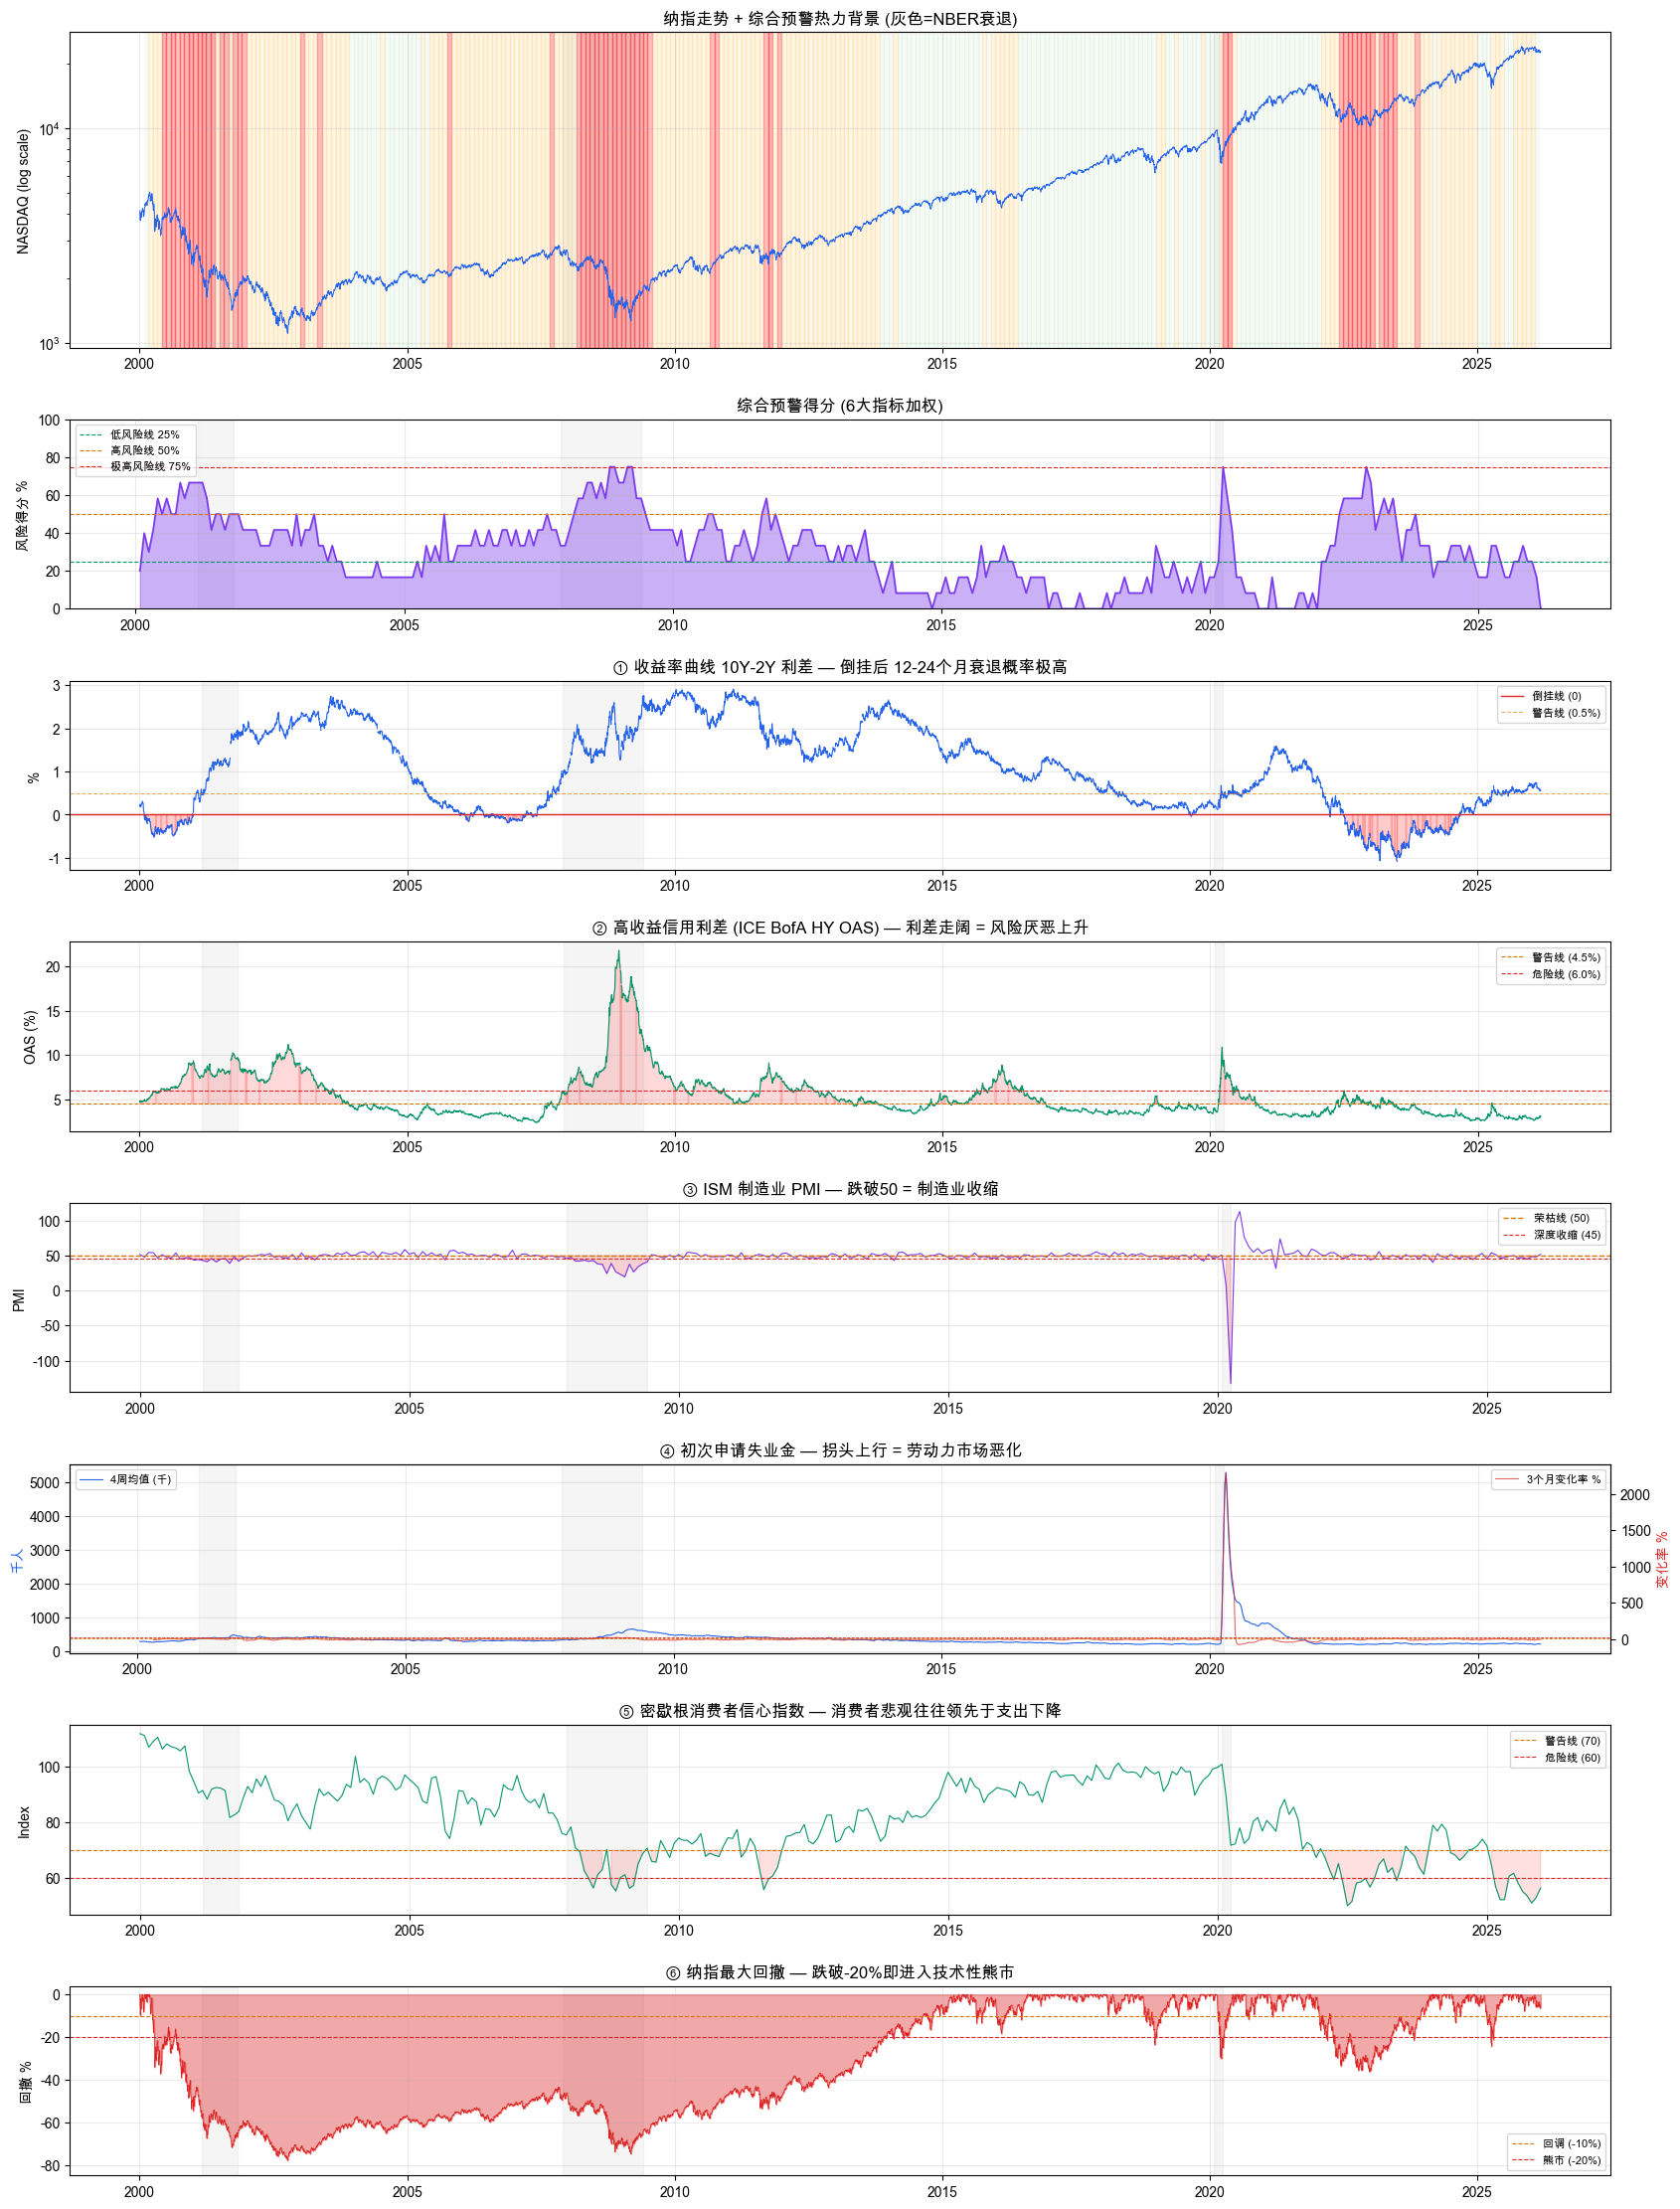

In [8]:
# %% [markdown]
# ## 熊市预警仪表盘 Bear Market Warning Dashboard
# 
# 综合6大类指标，每个指标根据历史阈值打分（0=安全, 1=警告, 2=危险），
# 最终合成一个综合预警分数。
#
# **需要 FRED API Key（免费）**:  
# 1. 去 https://fred.stlouisfed.org/docs/api/api_key.html 注册  
# 2. 把 key 填到下面 `FRED_API_KEY` 变量里
#
# ```
# pip install yfinance fredapi matplotlib numpy pandas
# ```

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import yfinance as yf
from fredapi import Fred
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── 中文字体 (macOS / Windows / Linux 自动适配) ──
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC"]
elif platform.system() == "Windows":
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
else:
    plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "Noto Sans CJK SC"]
plt.rcParams["axes.unicode_minus"] = False

# ═══════════════════════════════════════════════════════════════════════
# 配置
# ═══════════════════════════════════════════════════════════════════════
FRED_API_KEY = "f6fff570457de7b38053eb128d22940f"   # ← 填你的 key
fred = Fred(api_key=FRED_API_KEY)

START = "2000-01-01"
TODAY = datetime.today().strftime("%Y-%m-%d")

# ═══════════════════════════════════════════════════════════════════════
# 1. 拉取数据
# ═══════════════════════════════════════════════════════════════════════
print("拉取数据中...")

# ── 1a. 纳指 ──
nasdaq = yf.download("^IXIC", start=START, auto_adjust=True)["Close"]
if hasattr(nasdaq, "columns"):
    nasdaq = nasdaq.iloc[:, 0]
nasdaq.name = "NASDAQ"

# ── 1b. 收益率曲线: 10Y-2Y 利差 ──
spread_10y2y = fred.get_series("T10Y2Y", observation_start=START)
spread_10y2y.name = "10Y-2Y Spread"

# ── 1c. 10Y-3M 利差（另一个经典衰退指标）──
try:
    spread_10y3m = fred.get_series("T10Y3M", observation_start=START)
    spread_10y3m.name = "10Y-3M Spread"
except:
    gs10 = fred.get_series("GS10", observation_start=START)
    tb3m = fred.get_series("TB3MS", observation_start=START)
    spread_10y3m = gs10 - tb3m
    spread_10y3m.name = "10Y-3M Spread"

# ── 1d. 高收益信用利差 (ICE BofA HY OAS) ──
hy_spread = fred.get_series("BAMLH0A0HYM2", observation_start=START)
hy_spread.name = "HY Credit Spread"

# ── 1e. 联邦基金利率 ──
fed_funds = fred.get_series("FEDFUNDS", observation_start=START)
fed_funds.name = "Fed Funds Rate"

# ── 1f. ISM 制造业 PMI ── 
# 方案1: 用 FRED 的 NAPM (ISM Manufacturing PMI 的老代码，部分 key 可用)
try:
    ism_pmi = fred.get_series("NAPM", observation_start=START)
    ism_pmi.name = "ISM Manufacturing PMI"
    print("✅ 成功拉取 NAPM")
except:
    # 方案2: 用 ISM New Orders 子项 (NAPMNOI)，走势和 PMI 高度同步
    try:
        ism_pmi = fred.get_series("NAPMNOI", observation_start=START)
        ism_pmi.name = "ISM New Orders Index"
        print("✅ 成功拉取 NAPMNOI (New Orders)")
    except:
        # 方案3: 用 Chicago Fed National Activity Index 作为代理
        # CFNAI > 0 = 扩张, < 0 = 收缩，需要调整打分逻辑
        try:
            ism_pmi = fred.get_series("CFNAI", observation_start=START)
            # 转换到类 PMI 尺度: CFNAI 0 ≈ PMI 50
            ism_pmi = ism_pmi * 10 + 50
            ism_pmi.name = "CFNAI (rescaled to PMI)"
            print("✅ 成功拉取 CFNAI 作为 PMI 代理")
        except:
            print("❌ 无法获取 PMI 相关数据")
            ism_pmi = pd.Series(dtype=float)


# ── 1g. 初次申请失业金人数 ──
claims = fred.get_series("ICSA", observation_start=START)
claims.name = "Initial Claims"
claims_ma4 = claims.rolling(4).mean()  # 4周移动平均（去噪）

# ── 1h. 密歇根消费者信心指数 ──
umich = fred.get_series("UMCSENT", observation_start=START)
umich.name = "UMich Consumer Sentiment"

# ── 1i. Sahm Rule (实时衰退指标) ──
try:
    sahm = fred.get_series("SAHMREALTIME", observation_start=START)
    sahm.name = "Sahm Rule"
    has_sahm = True
except:
    has_sahm = False

print("数据拉取完成!")

# ═══════════════════════════════════════════════════════════════════════
# 2. 计算衍生指标
# ═══════════════════════════════════════════════════════════════════════

# 纳指技术面
nasdaq_df = nasdaq.to_frame("close")
nasdaq_df["ma200"] = nasdaq_df["close"].rolling(200).mean()
nasdaq_df["above_ma200"] = (nasdaq_df["close"] > nasdaq_df["ma200"]).astype(int)
nasdaq_df["drawdown"] = nasdaq_df["close"] / nasdaq_df["close"].cummax() - 1

# 初次失业金 — 3个月变化率 (拐头信号)
claims_chg = claims_ma4.pct_change(periods=13)  # 13周 ≈ 3个月
claims_chg.name = "Claims 3M Change"

# 收益率曲线 un-inversion 检测
# 当前值 vs 过去6个月最小值
spread_min_6m = spread_10y2y.rolling(window=126, min_periods=60).min()
uninversion = spread_10y2y - spread_min_6m  # 如果曲线在倒挂后快速变陡，这个值会很大

# ═══════════════════════════════════════════════════════════════════════
# 3. 打分函数 — 每个指标 0/1/2 分
# ═══════════════════════════════════════════════════════════════════════

def score_yield_curve(spread_val, was_inverted_recently):
    """收益率曲线: 倒挂=2, 曾倒挂且正在变陡(un-inversion)=2, 利差很窄(<0.5)=1"""
    if pd.isna(spread_val):
        return np.nan
    if spread_val < 0:
        return 2
    if was_inverted_recently and spread_val < 1.0:
        return 2  # un-inversion 阶段最危险
    if spread_val < 0.5:
        return 1
    return 0

def score_credit_spread(hy_val):
    """信用利差: >6%=2, >4.5%=1, else=0"""
    if pd.isna(hy_val):
        return np.nan
    if hy_val > 6:
        return 2
    if hy_val > 4.5:
        return 1
    return 0

def score_pmi(pmi_val):
    """ISM PMI: <45=2, <50=1, >=50=0"""
    if pd.isna(pmi_val):
        return np.nan
    if pmi_val < 45:
        return 2
    if pmi_val < 50:
        return 1
    return 0

def score_claims_change(chg_val):
    """失业金变化: >30%=2, >15%=1, else=0"""
    if pd.isna(chg_val):
        return np.nan
    if chg_val > 0.30:
        return 2
    if chg_val > 0.15:
        return 1
    return 0

def score_sentiment(umich_val):
    """消费者信心: <60=2, <70=1, else=0"""
    if pd.isna(umich_val):
        return np.nan
    if umich_val < 60:
        return 2
    if umich_val < 70:
        return 1
    return 0

def score_drawdown(dd_val):
    """纳指回撤: < -20%=2, < -10%=1, else=0"""
    if pd.isna(dd_val):
        return np.nan
    if dd_val < -0.20:
        return 2
    if dd_val < -0.10:
        return 1
    return 0

# ═══════════════════════════════════════════════════════════════════════
# 4. 对齐到月频 & 合成总分
# ═══════════════════════════════════════════════════════════════════════

# 统一 resample 到月末
monthly = pd.DataFrame(index=pd.date_range(START, TODAY, freq="ME"))

monthly["spread_10y2y"] = spread_10y2y.resample("ME").last()
monthly["spread_10y3m"] = spread_10y3m.resample("ME").last()
monthly["hy_spread"]    = hy_spread.resample("ME").last()
monthly["fed_funds"]    = fed_funds.resample("ME").last()
monthly["ism_pmi"]      = ism_pmi.resample("ME").last()
monthly["claims_ma4"]   = claims_ma4.resample("ME").last()
monthly["claims_chg"]   = claims_chg.resample("ME").last()
monthly["umich"]        = umich.resample("ME").last()
monthly["nasdaq_close"] = nasdaq.resample("ME").last()
monthly["nasdaq_dd"]    = nasdaq_df["drawdown"].resample("ME").last()
monthly["above_ma200"]  = nasdaq_df["above_ma200"].resample("ME").last()
if has_sahm:
    monthly["sahm"] = sahm.resample("ME").last()

# 过去6个月是否曾倒挂
monthly["was_inverted_6m"] = (
    monthly["spread_10y2y"].rolling(6).min() < 0
)

# 打分
monthly["s_yield"]     = monthly.apply(
    lambda r: score_yield_curve(r["spread_10y2y"], r["was_inverted_6m"]), axis=1)
monthly["s_credit"]    = monthly["hy_spread"].apply(score_credit_spread)
monthly["s_pmi"]       = monthly["ism_pmi"].apply(score_pmi)
monthly["s_claims"]    = monthly["claims_chg"].apply(score_claims_change)
monthly["s_sentiment"] = monthly["umich"].apply(score_sentiment)
monthly["s_drawdown"]  = monthly["nasdaq_dd"].apply(score_drawdown)

score_cols = ["s_yield", "s_credit", "s_pmi", "s_claims", "s_sentiment", "s_drawdown"]
monthly["total_score"] = monthly[score_cols].sum(axis=1)
monthly["max_possible"] = monthly[score_cols].notna().sum(axis=1) * 2
monthly["score_pct"] = monthly["total_score"] / monthly["max_possible"] * 100

# ═══════════════════════════════════════════════════════════════════════
# 5. 打印当前状态
# ═══════════════════════════════════════════════════════════════════════
latest = monthly.dropna(subset=["total_score"]).iloc[-1]
print("\n" + "=" * 60)
print(f"  熊市预警仪表盘 — {latest.name.strftime('%Y-%m')}")
print("=" * 60)

indicator_names = {
    "s_yield":     "收益率曲线 (10Y-2Y)",
    "s_credit":    "信用利差 (HY OAS)",
    "s_pmi":       "ISM 制造业 PMI",
    "s_claims":    "失业金申请趋势",
    "s_sentiment": "消费者信心指数",
    "s_drawdown":  "纳指回撤幅度",
}
status_emoji = {0: "🟢 安全", 1: "🟡 警告", 2: "🔴 危险"}

for col, name in indicator_names.items():
    val = latest[col]
    if pd.notna(val):
        print(f"  {name:<20s}  {status_emoji[int(val)]}")

print(f"\n  综合得分: {latest['total_score']:.0f} / {latest['max_possible']:.0f}"
      f"  ({latest['score_pct']:.0f}%)")
if latest["score_pct"] < 25:
    print("  📊 整体评估: 🟢 低风险")
elif latest["score_pct"] < 50:
    print("  📊 整体评估: 🟡 中等风险，需关注")
elif latest["score_pct"] < 75:
    print("  📊 整体评估: 🟠 高风险，保持警惕")
else:
    print("  📊 整体评估: 🔴 极高风险!")
print("=" * 60)

# ═══════════════════════════════════════════════════════════════════════
# 6. 画图 — 8个子图
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 28))
gs = gridspec.GridSpec(8, 1, height_ratios=[2.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5],
                       hspace=0.35)

# NBER 衰退阴影 (手动标注主要衰退期)
recessions = [
    ("2001-03-01", "2001-11-01"),  # dot-com
    ("2007-12-01", "2009-06-01"),  # GFC
    ("2020-02-01", "2020-04-01"),  # COVID
]

def add_recessions(ax):
    for start, end in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.08, color="gray", zorder=0)

def fmt(ax):
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    add_recessions(ax)

# ── Panel 1: 纳指 + 综合得分热力 ──
ax = fig.add_subplot(gs[0])
ax.plot(nasdaq.index, nasdaq.values, color="#2563eb", lw=0.7)
ax.set_yscale("log")
ax.set_ylabel("NASDAQ (log scale)")
ax.set_title("纳指走势 + 综合预警热力背景 (灰色=NBER衰退)", fontsize=12)

# 用颜色填充背景表示风险
for i in range(len(monthly) - 1):
    row = monthly.iloc[i]
    if pd.isna(row["score_pct"]):
        continue
    pct = row["score_pct"]
    if pct >= 50:
        c = "red"
        a = min(0.3, pct / 200)
    elif pct >= 25:
        c = "orange"
        a = 0.1
    else:
        c = "green"
        a = 0.03
    ax.axvspan(monthly.index[i], monthly.index[i + 1], alpha=a, color=c, zorder=0)
add_recessions(ax)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# ── Panel 2: 综合得分 ──
ax = fig.add_subplot(gs[1])
ax.fill_between(monthly.index, monthly["score_pct"], 0, color="#7c3aed", alpha=0.4)
ax.plot(monthly.index, monthly["score_pct"], color="#7c3aed", lw=1.2)
ax.axhline(25, color="#059669", ls="--", lw=0.8, label="低风险线 25%")
ax.axhline(50, color="#d97706", ls="--", lw=0.8, label="高风险线 50%")
ax.axhline(75, color="#dc2626", ls="--", lw=0.8, label="极高风险线 75%")
ax.set_ylabel("风险得分 %")
ax.set_title("综合预警得分 (6大指标加权)")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 100)
fmt(ax)

# ── Panel 3: 收益率曲线 10Y-2Y ──
ax = fig.add_subplot(gs[2])
ax.plot(spread_10y2y.index, spread_10y2y.values, color="#2563eb", lw=0.8)
ax.axhline(0, color="#dc2626", lw=1, ls="-", label="倒挂线 (0)")
ax.axhline(0.5, color="#d97706", lw=0.8, ls="--", alpha=0.6, label="警告线 (0.5%)")
ax.fill_between(spread_10y2y.index, spread_10y2y.values, 0,
                where=spread_10y2y.values < 0, alpha=0.2, color="red")
ax.set_ylabel("%")
ax.set_title("① 收益率曲线 10Y-2Y 利差 — 倒挂后 12-24个月衰退概率极高")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 4: 高收益信用利差 ──
ax = fig.add_subplot(gs[3])
ax.plot(hy_spread.index, hy_spread.values, color="#059669", lw=0.8)
ax.axhline(4.5, color="#d97706", lw=0.8, ls="--", label="警告线 (4.5%)")
ax.axhline(6.0, color="#dc2626", lw=0.8, ls="--", label="危险线 (6.0%)")
ax.fill_between(hy_spread.index, hy_spread.values, 4.5,
                where=hy_spread.values > 4.5, alpha=0.15, color="red")
ax.set_ylabel("OAS (%)")
ax.set_title("② 高收益信用利差 (ICE BofA HY OAS) — 利差走阔 = 风险厌恶上升")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 5: ISM 制造业 PMI ──
ax = fig.add_subplot(gs[4])
ax.plot(ism_pmi.index, ism_pmi.values, color="#7c3aed", lw=0.8)
ax.axhline(50, color="#d97706", lw=1, ls="--", label="荣枯线 (50)")
ax.axhline(45, color="#dc2626", lw=0.8, ls="--", label="深度收缩 (45)")
ax.fill_between(ism_pmi.index, ism_pmi.values, 50,
                where=ism_pmi.values < 50, alpha=0.15, color="red")
ax.set_ylabel("PMI")
ax.set_title("③ ISM 制造业 PMI — 跌破50 = 制造业收缩")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 6: 初次失业金申请 + 3个月变化率 ──
ax = fig.add_subplot(gs[5])
ax2 = ax.twinx()
ax.plot(claims_ma4.index, claims_ma4.values / 1000, color="#2563eb", lw=0.8, label="4周均值 (千)")
ax2.plot(claims_chg.index, claims_chg.values * 100, color="#dc2626", lw=0.8, alpha=0.7, label="3个月变化率 %")
ax2.axhline(15, color="#d97706", ls="--", lw=0.6)
ax2.axhline(30, color="#dc2626", ls="--", lw=0.6)
ax.set_ylabel("千人", color="#2563eb")
ax2.set_ylabel("变化率 %", color="#dc2626")
ax.set_title("④ 初次申请失业金 — 拐头上行 = 劳动力市场恶化")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 7: 密歇根消费者信心 ──
ax = fig.add_subplot(gs[6])
ax.plot(umich.index, umich.values, color="#059669", lw=0.8)
ax.axhline(70, color="#d97706", lw=0.8, ls="--", label="警告线 (70)")
ax.axhline(60, color="#dc2626", lw=0.8, ls="--", label="危险线 (60)")
ax.fill_between(umich.index, umich.values, 70,
                where=umich.values < 70, alpha=0.12, color="red")
ax.set_ylabel("Index")
ax.set_title("⑤ 密歇根消费者信心指数 — 消费者悲观往往领先于支出下降")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 8: 纳指回撤 ──
ax = fig.add_subplot(gs[7])
dd = nasdaq_df["drawdown"]
ax.fill_between(dd.index, dd.values * 100, 0, color="#dc2626", alpha=0.4)
ax.plot(dd.index, dd.values * 100, color="#dc2626", lw=0.5)
ax.axhline(-10, color="#d97706", ls="--", lw=0.8, label="回调 (-10%)")
ax.axhline(-20, color="#dc2626", ls="--", lw=0.8, label="熊市 (-20%)")
ax.set_ylabel("回撤 %")
ax.set_title("⑥ 纳指最大回撤 — 跌破-20%即进入技术性熊市")
ax.legend(loc="lower right", fontsize=8)
ax.set_ylim(bottom=min(dd.min() * 100 - 5, -85))
fmt(ax)

plt.savefig("bear_market_dashboard.png", dpi=150, bbox_inches="tight")
print("\n图表已保存 → bear_market_dashboard.png")
plt.show()

拉取领先指标数据...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  ✅ 银行贷款标准
  ✅ 收益率曲线
  ✅ M2 货币供应


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  ✅ 市场宽度 (RSP vs SPY)
  ✅ 企业利润
  ✅ 实际利率 (TIPS)

数据拉取完成!

═════════════════════════════════════════════════════════════════
  熊市领先指标仪表盘 V2 — 2026-02
═════════════════════════════════════════════════════════════════
  🟢 收益率曲线 (un-inv)                   0.59%  →  安全
  🟡 10Y实际利率                          1.72%  →  警告

  综合得分: 1.0 / 4  (25%)
  🟡 中等风险 — 部分领先指标亮灯，保持关注
═════════════════════════════════════════════════════════════════

图表已保存 → bear_market_leading_v2.png


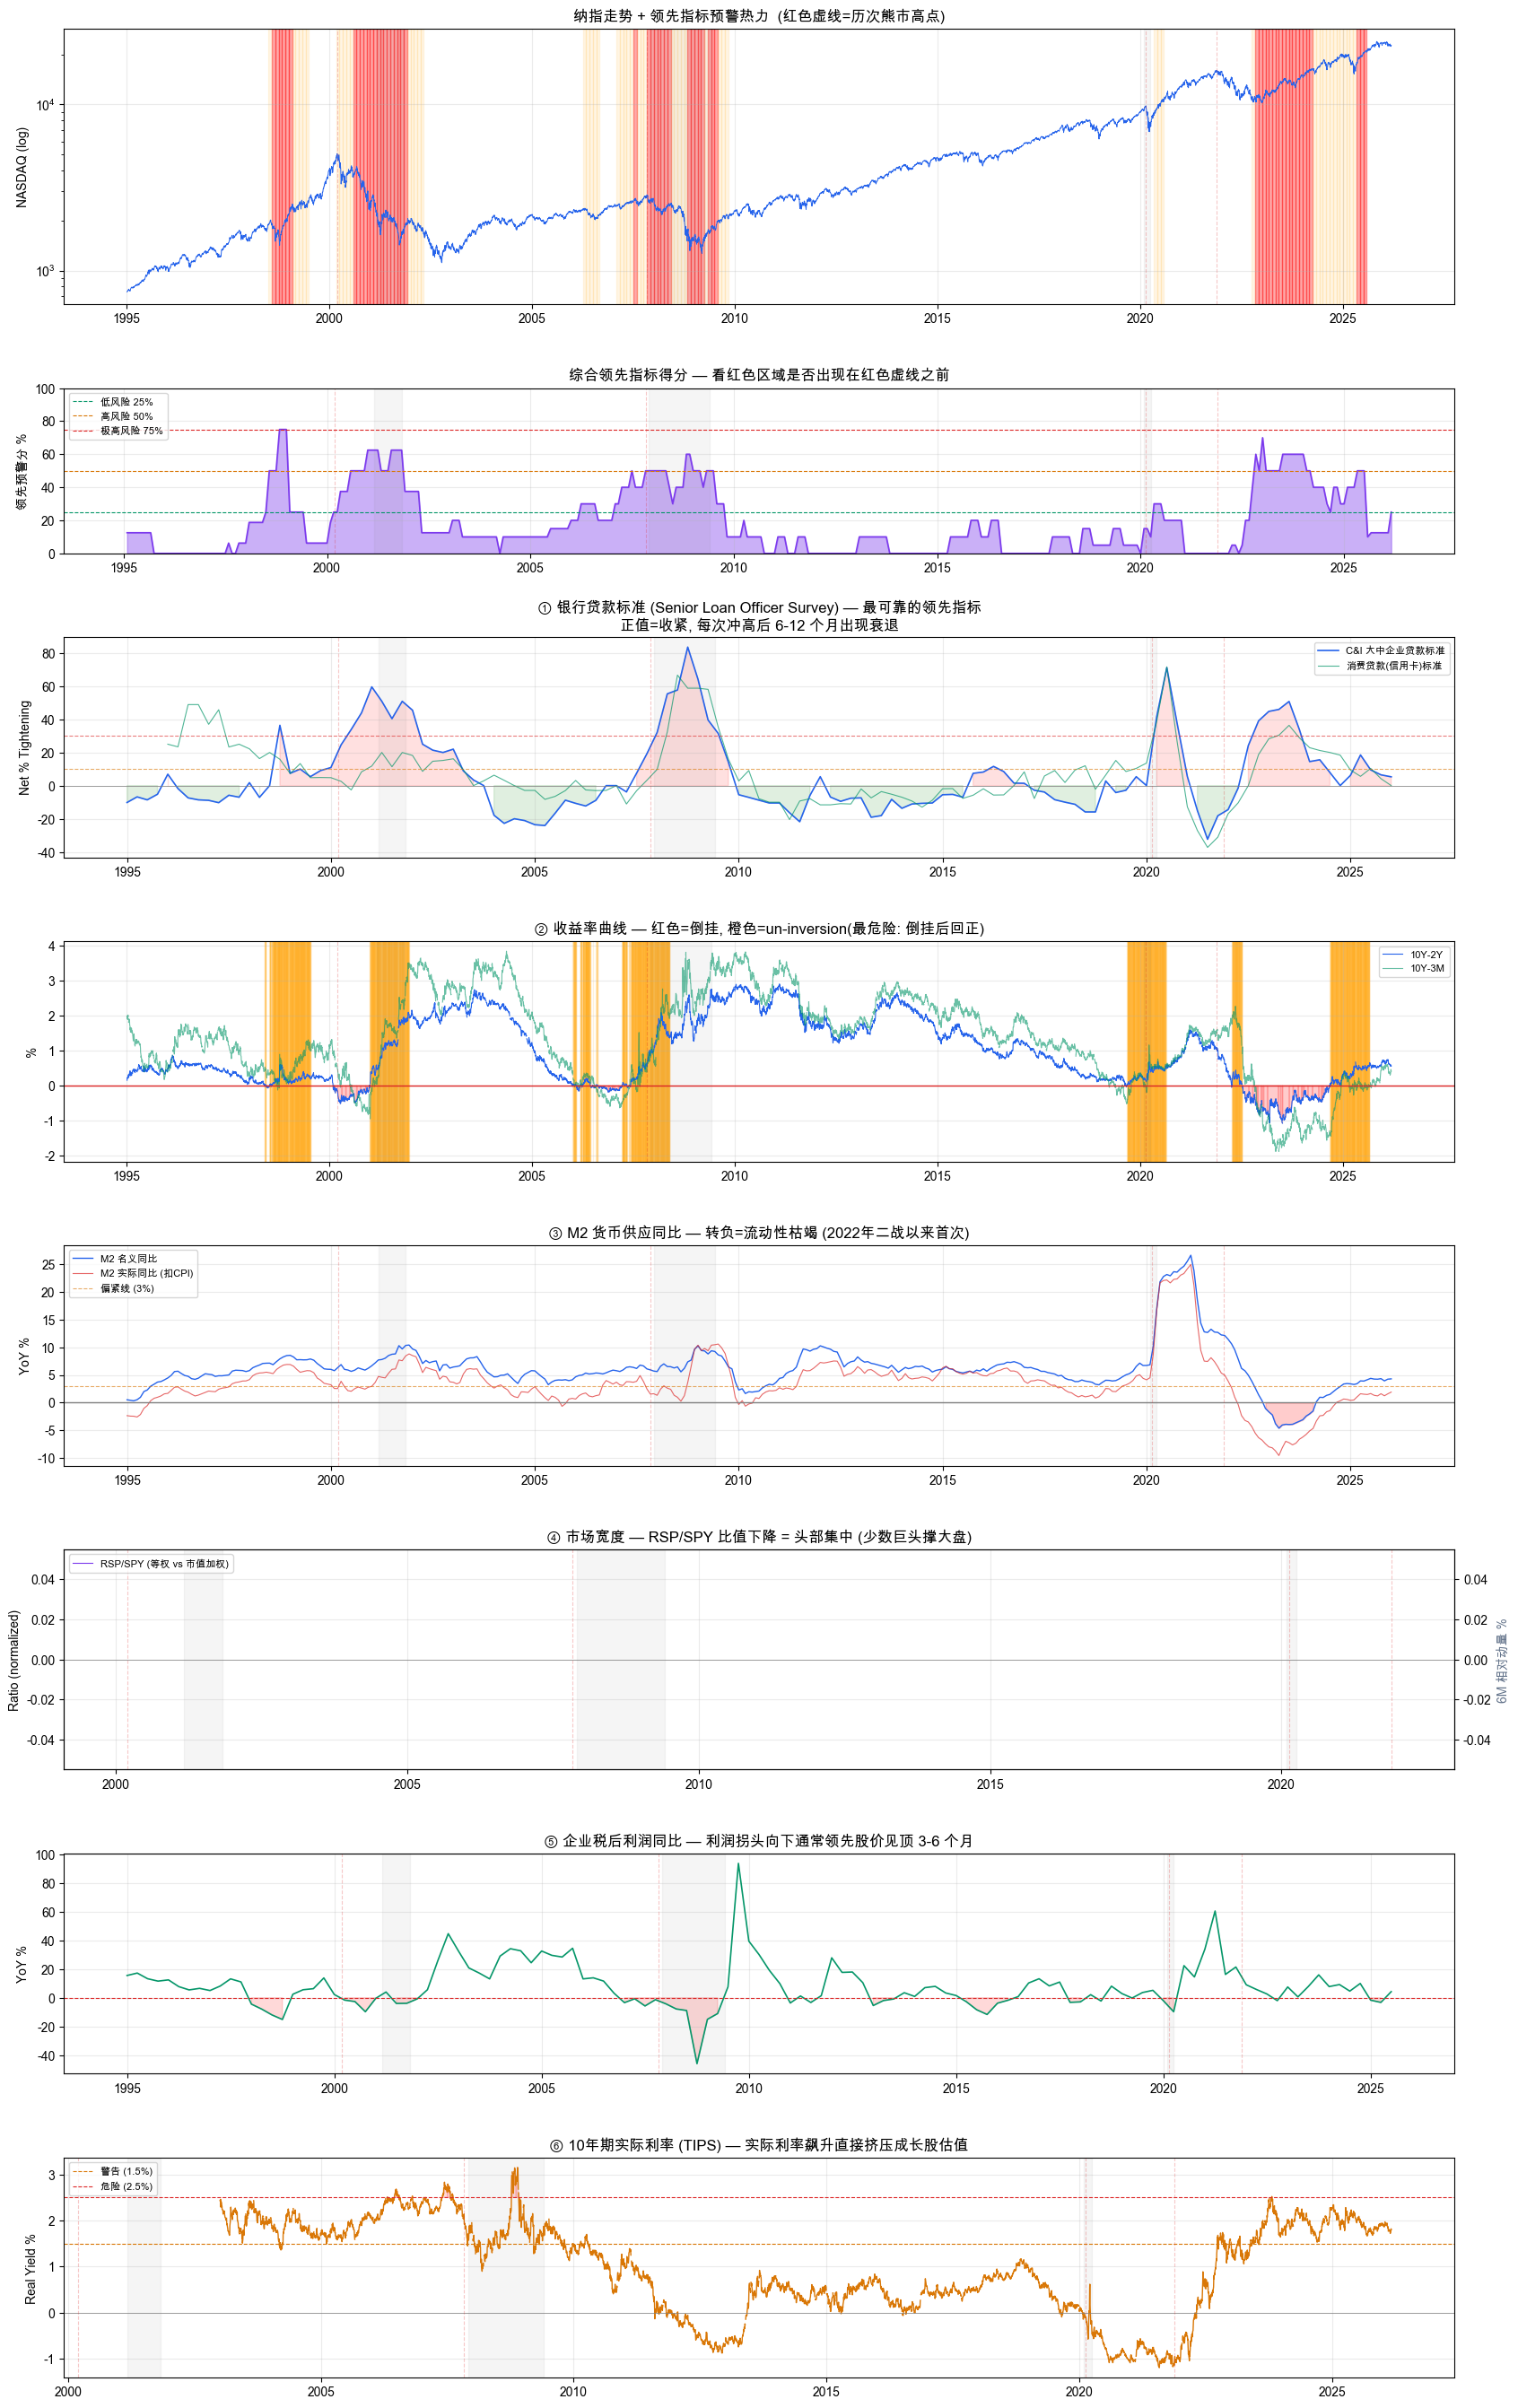

In [9]:
# %% [markdown]
# ## 熊市预警 V2 — 真正的领先指标
#
# V1 的问题：大部分指标是同步/滞后的，看到的时候已经在跌了。  
# V2 聚焦于 **历史上真正领先于熊市 6-18 个月** 的信号：
#
# | 指标 | 领先时间 | 逻辑 |
# |------|---------|------|
# | 银行收紧贷款标准 | 6-12个月 | 银行先收紧 → 企业缺钱 → 裁员 → 衰退 |
# | 收益率曲线 un-inversion | 3-12个月 | 倒挂不可怕，**恢复正常**才是衰退前兆 |
# | M2 货币供应同比 | 6-12个月 | 流动性枯竭 → 资产价格承压 |
# | 市场宽度背离 | 3-9个月 | 大盘涨但多数股票不涨 = 头部信号 |
# | 企业利润增速拐头 | 3-6个月 | 利润先见顶，股价后见顶 |
# | 期限溢价 / 实际利率 | 3-9个月 | 实际融资成本飙升 → 挤压估值 |

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import yfinance as yf
from fredapi import Fred
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 中文字体 ──
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC"]
elif platform.system() == "Windows":
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
else:
    plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "Noto Sans CJK SC"]
plt.rcParams["axes.unicode_minus"] = False

# ── 配置 (复用你之前的 FRED key) ──
# FRED_API_KEY = "YOUR_KEY"   # 如果前面的 cell 已经定义了就不用重复
# fred = Fred(api_key=FRED_API_KEY)

START = "1995-01-01"
TODAY = datetime.today().strftime("%Y-%m-%d")

# ═══════════════════════════════════════════════════════════════════════
# 1. 拉取数据
# ═══════════════════════════════════════════════════════════════════════
print("拉取领先指标数据...")

# ── 纳指 ──
nasdaq = yf.download("^IXIC", start=START, auto_adjust=True)["Close"]
if hasattr(nasdaq, "columns"):
    nasdaq = nasdaq.iloc[:, 0]

# ── 标普500 (用于宽度比较) ──
sp500 = yf.download("^GSPC", start=START, auto_adjust=True)["Close"]
if hasattr(sp500, "columns"):
    sp500 = sp500.iloc[:, 0]

# ──────────────────────────────────────────────────────────────────────
# 领先指标 1: 银行贷款标准 (Senior Loan Officer Survey)
#   正值 = 收紧, 负值 = 放松
#   领先衰退 6-12 个月，这是最靠谱的单一领先指标
# ──────────────────────────────────────────────────────────────────────
# C&I 贷款标准（大中型企业）
loan_std_ci = fred.get_series("DRTSCILM", observation_start=START)
loan_std_ci.name = "C&I Loan Standards (Large+Mid)"

# 消费贷款标准（信用卡）
try:
    loan_std_cc = fred.get_series("DRTSCLCC", observation_start=START)
    loan_std_cc.name = "Consumer Loan Standards (Credit Card)"
except:
    loan_std_cc = None

print("  ✅ 银行贷款标准")

# ──────────────────────────────────────────────────────────────────────
# 领先指标 2: 收益率曲线 — 倒挂深度 + un-inversion 检测
# ──────────────────────────────────────────────────────────────────────
spread_10y2y = fred.get_series("T10Y2Y", observation_start=START)
# 10Y-3M 更准（纽约联储用这个算衰退概率）
try:
    spread_10y3m = fred.get_series("T10Y3M", observation_start=START)
except:
    gs10 = fred.get_series("GS10", observation_start=START)
    tb3m = fred.get_series("TB3MS", observation_start=START)
    spread_10y3m = gs10 - tb3m

# 计算: 过去12个月最小值（用来检测是否经历过倒挂）
spread_rolling_min_12m = spread_10y2y.rolling(window=252, min_periods=60).min()
# un-inversion 信号: 曾经倒挂 + 现在回正
was_inverted = spread_rolling_min_12m < 0
is_positive_now = spread_10y2y > 0
uninversion_signal = was_inverted & is_positive_now

print("  ✅ 收益率曲线")

# ──────────────────────────────────────────────────────────────────────
# 领先指标 3: M2 货币供应量同比增速
#   流动性是一切资产价格的根基
#   M2 同比转负 → 历史上极为罕见 → 2022年首次出现以来纳指暴跌
# ──────────────────────────────────────────────────────────────────────
m2 = fred.get_series("M2SL", observation_start="1994-01-01")  # 多拉一年算同比
m2_yoy = m2.pct_change(periods=12) * 100  # 12个月同比，百分比
m2_yoy = m2_yoy[m2_yoy.index >= START]
m2_yoy.name = "M2 YoY %"

# M2 减去 CPI 同比 = 实际流动性增速
try:
    cpi = fred.get_series("CPIAUCSL", observation_start="1994-01-01")
    cpi_yoy = cpi.pct_change(periods=12) * 100
    real_m2_yoy = m2_yoy - cpi_yoy[cpi_yoy.index >= START]
    real_m2_yoy.name = "Real M2 YoY %"
    has_real_m2 = True
except:
    has_real_m2 = False

print("  ✅ M2 货币供应")

# ──────────────────────────────────────────────────────────────────────
# 领先指标 4: 市场宽度 (Breadth)
#   用 NYSE Advance-Decline 数据 (如果可用)
#   简易替代: 等权 ETF (RSP) vs 市值加权 (SPY) 的相对强度
#   背离 = 多数股票不参与上涨 = 顶部信号
# ──────────────────────────────────────────────────────────────────────
# 方法: 用 %股票在200日均线以上 的比例
# FRED 没有直接数据，用 SPY vs RSP (等权S&P500)
try:
    rsp = yf.download("RSP", start="2003-01-01", auto_adjust=True)["Close"]
    spy = yf.download("SPY", start="2003-01-01", auto_adjust=True)["Close"]
    if hasattr(rsp, "columns"):
        rsp = rsp.iloc[:, 0]
    if hasattr(spy, "columns"):
        spy = spy.iloc[:, 0]
    # 相对强度: RSP/SPY 的 6个月变化
    breadth_ratio = (rsp / spy)
    breadth_ratio = breadth_ratio / breadth_ratio.iloc[0]  # 归一化
    # 6个月相对变化率: 正 = 多数股票跑赢 (健康), 负 = 少数巨头撑着 (危险)
    breadth_momentum = breadth_ratio.pct_change(periods=126) * 100
    breadth_momentum.name = "Equal vs Cap-Weight 6M Rel %"
    has_breadth = True
    print("  ✅ 市场宽度 (RSP vs SPY)")
except Exception as e:
    has_breadth = False
    print(f"  ⚠️ 市场宽度数据不可用: {e}")

# ──────────────────────────────────────────────────────────────────────
# 领先指标 5: 企业利润增速
#   FRED: CP (Corporate Profits After Tax)
#   利润同比增速拐头 → 领先股市见顶 3-6 个月
# ──────────────────────────────────────────────────────────────────────
try:
    corp_profits = fred.get_series("CP", observation_start="1994-01-01")
    cp_yoy = corp_profits.pct_change(periods=4) * 100  # 季度数据，4期=同比
    cp_yoy = cp_yoy[cp_yoy.index >= START]
    cp_yoy.name = "Corporate Profits YoY %"
    has_cp = True
    print("  ✅ 企业利润")
except:
    has_cp = False
    print("  ⚠️ 企业利润数据不可用")

# ──────────────────────────────────────────────────────────────────────
# 领先指标 6: 实际利率 (10Y TIPS yield)
#   实际利率飙升 → 直接挤压估值和借贷成本
# ──────────────────────────────────────────────────────────────────────
try:
    tips_10y = fred.get_series("DFII10", observation_start=START)
    tips_10y.name = "10Y Real Rate (TIPS)"
    has_tips = True
    print("  ✅ 实际利率 (TIPS)")
except:
    try:
        tips_10y = fred.get_series("REAINTRATREARAT10Y", observation_start=START)
        tips_10y.name = "10Y Real Rate"
        has_tips = True
        print("  ✅ 实际利率")
    except:
        has_tips = False
        print("  ⚠️ 实际利率数据不可用")

print("\n数据拉取完成!")

# ═══════════════════════════════════════════════════════════════════════
# 2. 领先指标打分 (月频)
# ═══════════════════════════════════════════════════════════════════════
monthly = pd.DataFrame(index=pd.date_range(START, TODAY, freq="ME"))

monthly["nasdaq"] = nasdaq.resample("ME").last()
monthly["loan_std"] = loan_std_ci.resample("ME").last().ffill()
monthly["spread_10y2y"] = spread_10y2y.resample("ME").last()
monthly["m2_yoy"] = m2_yoy.resample("ME").last()
if has_real_m2:
    monthly["real_m2_yoy"] = real_m2_yoy.resample("ME").last()
if has_breadth:
    monthly["breadth_mom"] = breadth_momentum.resample("ME").last()
if has_cp:
    monthly["cp_yoy"] = cp_yoy.resample("ME").last().ffill()
if has_tips:
    monthly["real_rate"] = tips_10y.resample("ME").last()

# 过去12个月是否倒挂过
monthly["was_inverted_12m"] = monthly["spread_10y2y"].rolling(12).min() < 0
monthly["uninversion"] = monthly["was_inverted_12m"] & (monthly["spread_10y2y"] > 0)


# ── 打分函数 ──
def s_loan(v):
    """银行收紧贷款: >30=2(大幅收紧), >10=1(轻度收紧)"""
    if pd.isna(v): return np.nan
    if v > 30: return 2
    if v > 10: return 1
    return 0

def s_curve(spread, uninv):
    """收益率曲线: 倒挂=1, un-inversion=2(最危险阶段)"""
    if pd.isna(spread): return np.nan
    if uninv:  return 2  # 曾经倒挂+现在回正 = 衰退即将到来
    if spread < 0: return 1  # 正在倒挂 = 预警但不一定马上
    if spread < 0.3: return 0.5
    return 0

def s_m2(v):
    """M2同比: <0=2(历史罕见), <3%=1(偏紧)"""
    if pd.isna(v): return np.nan
    if v < 0:  return 2
    if v < 3:  return 1
    return 0

def s_breadth(v):
    """市场宽度: <-5%=2(严重背离), <-2%=1"""
    if pd.isna(v): return np.nan
    if v < -5: return 2
    if v < -2: return 1
    return 0

def s_cp(v):
    """企业利润同比: <-10%=2, <0%=1"""
    if pd.isna(v): return np.nan
    if v < -10: return 2
    if v < 0:   return 1
    return 0

def s_real_rate(v):
    """实际利率: >2.5%=2(严重挤压), >1.5%=1"""
    if pd.isna(v): return np.nan
    if v > 2.5: return 2
    if v > 1.5: return 1
    return 0

# 应用打分
monthly["s_loan"]  = monthly["loan_std"].apply(s_loan)
monthly["s_curve"] = monthly.apply(lambda r: s_curve(r["spread_10y2y"], r["uninversion"]), axis=1)
monthly["s_m2"]    = monthly["m2_yoy"].apply(s_m2)

score_cols = ["s_loan", "s_curve", "s_m2"]

if has_breadth:
    monthly["s_breadth"] = monthly["breadth_mom"].apply(s_breadth)
    score_cols.append("s_breadth")
if has_cp:
    monthly["s_cp"] = monthly["cp_yoy"].apply(s_cp)
    score_cols.append("s_cp")
if has_tips:
    monthly["s_rate"] = monthly["real_rate"].apply(s_real_rate)
    score_cols.append("s_rate")

monthly["total"]  = monthly[score_cols].sum(axis=1)
monthly["max_sc"] = monthly[score_cols].notna().sum(axis=1) * 2
monthly["pct"]    = monthly["total"] / monthly["max_sc"] * 100

# ═══════════════════════════════════════════════════════════════════════
# 3. 打印当前状态
# ═══════════════════════════════════════════════════════════════════════
latest = monthly.dropna(subset=["total"]).iloc[-1]

indicator_info = {
    "s_loan":    ("银行贷款标准收紧度",     "loan_std",    "{:.1f}% net tightening"),
    "s_curve":   ("收益率曲线 (un-inv)",     "spread_10y2y","{:.2f}%"),
    "s_m2":      ("M2 货币同比增速",         "m2_yoy",      "{:.1f}%"),
}
if has_breadth:
    indicator_info["s_breadth"] = ("市场宽度背离", "breadth_mom", "{:.1f}%")
if has_cp:
    indicator_info["s_cp"] = ("企业利润同比", "cp_yoy", "{:.1f}%")
if has_tips:
    indicator_info["s_rate"] = ("10Y实际利率", "real_rate", "{:.2f}%")

emoji = {0: "🟢", 0.5: "🟡", 1: "🟡", 2: "🔴"}

print("\n" + "═" * 65)
print(f"  熊市领先指标仪表盘 V2 — {latest.name.strftime('%Y-%m')}")
print("═" * 65)
for sc, (name, raw, fmt_str) in indicator_info.items():
    sv = latest[sc]
    rv = latest.get(raw, np.nan)
    if pd.notna(sv):
        e = emoji.get(sv, "🟡")
        rv_str = fmt_str.format(rv) if pd.notna(rv) else "N/A"
        score_label = ["安全", "警告", "危险"][min(int(sv), 2)]
        print(f"  {e} {name:<18s}  {rv_str:>18s}  →  {score_label}")

print(f"\n  综合得分: {latest['total']:.1f} / {latest['max_sc']:.0f}"
      f"  ({latest['pct']:.0f}%)")
if latest["pct"] < 25:
    level = "🟢 低风险 — 领先指标暂无衰退信号"
elif latest["pct"] < 50:
    level = "🟡 中等风险 — 部分领先指标亮灯，保持关注"
elif latest["pct"] < 75:
    level = "🟠 高风险 — 多个领先指标预警，建议降低仓位"
else:
    level = "🔴 极高风险 — 历史上类似组合后 6-12 个月大概率衰退"
print(f"  {level}")
print("═" * 65)

# ═══════════════════════════════════════════════════════════════════════
# 4. 画图 — 8 panels
# ═══════════════════════════════════════════════════════════════════════
n_panels = 8
fig = plt.figure(figsize=(20, 34))
gs = gridspec.GridSpec(n_panels, 1,
                       height_ratios=[2.5, 1.5, 2, 2, 2, 2, 2, 2],
                       hspace=0.38)

recessions = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]
# 纳指熊市高点（用于验证指标是否提前亮灯）
bear_peaks = {
    "2000-03 科网泡沫": "2000-03-10",
    "2007-10 金融危机": "2007-10-31",
    "2020-02 COVID":    "2020-02-19",
    "2021-11 加息周期": "2021-11-19",
}

def add_bg(ax):
    for s, e in recessions:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color="gray")
    for label, d in bear_peaks.items():
        ax.axvline(pd.Timestamp(d), color="#dc2626", alpha=0.25, ls="--", lw=0.8)

def fmt(ax):
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    add_bg(ax)

# ── Panel 1: 纳指 + 领先指标热力背景 ──
ax = fig.add_subplot(gs[0])
ax.plot(nasdaq.index, nasdaq.values, color="#2563eb", lw=0.7)
ax.set_yscale("log")
ax.set_ylabel("NASDAQ (log)")
ax.set_title("纳指走势 + 领先指标预警热力  (红色虚线=历次熊市高点)", fontsize=12)
for i in range(len(monthly) - 1):
    p = monthly.iloc[i]["pct"]
    if pd.isna(p): continue
    if p >= 50:
        ax.axvspan(monthly.index[i], monthly.index[i+1], alpha=min(0.35, p/150), color="red")
    elif p >= 25:
        ax.axvspan(monthly.index[i], monthly.index[i+1], alpha=0.10, color="orange")
fmt(ax)

# ── Panel 2: 综合得分 ──
ax = fig.add_subplot(gs[1])
ax.fill_between(monthly.index, monthly["pct"], 0, color="#7c3aed", alpha=0.4)
ax.plot(monthly.index, monthly["pct"], color="#7c3aed", lw=1.2)
ax.axhline(25, color="#059669", ls="--", lw=0.8, label="低风险 25%")
ax.axhline(50, color="#d97706", ls="--", lw=0.8, label="高风险 50%")
ax.axhline(75, color="#dc2626", ls="--", lw=0.8, label="极高风险 75%")
ax.set_ylabel("领先预警分 %")
ax.set_title("综合领先指标得分 — 看红色区域是否出现在红色虚线之前")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 100)
fmt(ax)

# ── Panel 3: 银行贷款标准 (最重要的领先指标) ──
ax = fig.add_subplot(gs[2])
ax.plot(loan_std_ci.index, loan_std_ci.values, color="#2563eb", lw=1.2,
        label="C&I 大中企业贷款标准")
if loan_std_cc is not None:
    ax.plot(loan_std_cc.index, loan_std_cc.values, color="#059669", lw=0.8,
            alpha=0.7, label="消费贷款(信用卡)标准")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(10, color="#d97706", ls="--", lw=0.8, alpha=0.6)
ax.axhline(30, color="#dc2626", ls="--", lw=0.8, alpha=0.6)
ax.fill_between(loan_std_ci.index, loan_std_ci.values, 0,
                where=loan_std_ci.values > 0, alpha=0.12, color="red")
ax.fill_between(loan_std_ci.index, loan_std_ci.values, 0,
                where=loan_std_ci.values < 0, alpha=0.12, color="green")
ax.set_ylabel("Net % Tightening")
ax.set_title("① 银行贷款标准 (Senior Loan Officer Survey) — 最可靠的领先指标\n"
             "正值=收紧, 每次冲高后 6-12 个月出现衰退")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 4: 收益率曲线 + un-inversion 标记 ──
ax = fig.add_subplot(gs[3])
ax.plot(spread_10y2y.index, spread_10y2y.values, color="#2563eb", lw=0.8, label="10Y-2Y")
ax.plot(spread_10y3m.index, spread_10y3m.values, color="#059669", lw=0.8,
        alpha=0.6, label="10Y-3M")
ax.axhline(0, color="#dc2626", lw=1)
ax.fill_between(spread_10y2y.index, spread_10y2y.values, 0,
                where=spread_10y2y.values < 0, alpha=0.2, color="red")

# 标记 un-inversion 区间
uninv_daily = uninversion_signal.reindex(spread_10y2y.index).ffill().fillna(False)
for i in range(len(uninv_daily) - 1):
    if uninv_daily.iloc[i]:
        ax.axvspan(uninv_daily.index[i], uninv_daily.index[min(i+1, len(uninv_daily)-1)],
                   alpha=0.15, color="orange")

ax.set_ylabel("%")
ax.set_title("② 收益率曲线 — 红色=倒挂, 橙色=un-inversion(最危险: 倒挂后回正)")
ax.legend(loc="upper right", fontsize=8)
fmt(ax)

# ── Panel 5: M2 同比 + 实际M2同比 ──
ax = fig.add_subplot(gs[4])
ax.plot(m2_yoy.index, m2_yoy.values, color="#2563eb", lw=1, label="M2 名义同比")
if has_real_m2:
    ax.plot(real_m2_yoy.index, real_m2_yoy.values, color="#dc2626", lw=0.8,
            alpha=0.7, label="M2 实际同比 (扣CPI)")
ax.axhline(0, color="gray", lw=1)
ax.axhline(3, color="#d97706", ls="--", lw=0.8, alpha=0.6, label="偏紧线 (3%)")
ax.fill_between(m2_yoy.index, m2_yoy.values, 0,
                where=m2_yoy.values < 0, alpha=0.2, color="red")
ax.set_ylabel("YoY %")
ax.set_title("③ M2 货币供应同比 — 转负=流动性枯竭 (2022年二战以来首次)")
ax.legend(loc="upper left", fontsize=8)
fmt(ax)

# ── Panel 6: 市场宽度 ──
ax = fig.add_subplot(gs[5])
if has_breadth:
    ax.plot(breadth_ratio.index, breadth_ratio.values, color="#7c3aed", lw=0.8,
            label="RSP/SPY (等权 vs 市值加权)")
    ax.set_ylabel("Ratio (normalized)")
    ax.set_title("④ 市场宽度 — RSP/SPY 比值下降 = 头部集中 (少数巨头撑大盘)")
    ax.legend(loc="upper left", fontsize=8)
    # 叠加6个月动量
    ax2 = ax.twinx()
    ax2.bar(breadth_momentum.index, breadth_momentum.values,
            width=5, alpha=0.3,
            color=np.where(breadth_momentum.values < 0, "red", "green"))
    ax2.set_ylabel("6M 相对动量 %", color="#64748b")
    ax2.axhline(0, color="gray", lw=0.5)
else:
    ax.text(0.5, 0.5, "RSP 数据不可用 (ETF 2003年后才有)",
            transform=ax.transAxes, ha="center", fontsize=12, color="gray")
    ax.set_title("④ 市场宽度 — 数据不可用")
fmt(ax)

# ── Panel 7: 企业利润同比 ──
ax = fig.add_subplot(gs[6])
if has_cp:
    ax.plot(cp_yoy.index, cp_yoy.values, color="#059669", lw=1.2)
    ax.axhline(0, color="#dc2626", lw=0.8, ls="--")
    ax.fill_between(cp_yoy.index, cp_yoy.values, 0,
                    where=cp_yoy.values < 0, alpha=0.15, color="red")
    ax.set_ylabel("YoY %")
    ax.set_title("⑤ 企业税后利润同比 — 利润拐头向下通常领先股价见顶 3-6 个月")
else:
    ax.text(0.5, 0.5, "企业利润数据不可用", transform=ax.transAxes,
            ha="center", fontsize=12, color="gray")
    ax.set_title("⑤ 企业利润同比")
fmt(ax)

# ── Panel 8: 实际利率 ──
ax = fig.add_subplot(gs[7])
if has_tips:
    ax.plot(tips_10y.index, tips_10y.values, color="#d97706", lw=1)
    ax.axhline(1.5, color="#d97706", ls="--", lw=0.8, label="警告 (1.5%)")
    ax.axhline(2.5, color="#dc2626", ls="--", lw=0.8, label="危险 (2.5%)")
    ax.axhline(0, color="gray", lw=0.5)
    ax.fill_between(tips_10y.index, tips_10y.values, 2.5,
                    where=tips_10y.values > 2.5, alpha=0.15, color="red")
    ax.set_ylabel("Real Yield %")
    ax.set_title("⑥ 10年期实际利率 (TIPS) — 实际利率飙升直接挤压成长股估值")
    ax.legend(loc="upper left", fontsize=8)
else:
    ax.text(0.5, 0.5, "TIPS 数据不可用", transform=ax.transAxes,
            ha="center", fontsize=12, color="gray")
    ax.set_title("⑥ 实际利率")
fmt(ax)

plt.savefig("bear_market_leading_v2.png", dpi=150, bbox_inches="tight")
print("\n图表已保存 → bear_market_leading_v2.png")
plt.show()

# %% [markdown]
# ### 怎么用这个仪表盘
#
# **核心逻辑**: 不要等所有指标都亮红灯（那时候已经在跌了），
# 而是关注 **第一个领先指标亮灯 → 第二个跟上** 的过程。
#
# 历史上的规律:
# - **2000年**: 银行先收紧 (1999H2) → 收益率倒挂 (2000初) → 宽度背离 (大盘涨但多数股票跌) → 3月见顶
# - **2007年**: 银行收紧 (2007Q1) → 收益率曾倒挂 (2006) → 企业利润拐头 → 10月见顶
# - **2022年**: M2转负 (2022初) → 实际利率飙升 → 银行收紧 → 但没有衰退（软着陆）
#
# **关键洞察**: 银行贷款标准是最靠谱的单一指标。
# 每次它冲上30%以上，后面6-12个月都不太平。
# 但即使它也不是100%准确——2022年收紧了但经济撑住了。
# 所以要**多指标交叉验证**，至少2-3个同时亮灯才值得行动。